# PDD / Exit Dose / Exit Fluence Comparison Workflow

This notebook is organized in **clean blocks** so you can:
1. Load simulation outputs (`pdd`, `exitDose`, `exitFluence`) from text files.
2. Compare simulated PDD against your measured curves for each applicator and mode.
3. Compare exit-dose and exit-fluence in practical, physics-based ways.
4. Estimate source-parameter changes to improve simulation-vs-measurement agreement.

## 1) Imports and plot style

In [20]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10



## 2) Measured PDD library (your provided data)

Use key format: `(applicator_cm, mode)` where mode is one of: `flash9`, `conv9`, `flash6alt`.

In [21]:
MEASURED_PDD = {
    (10, 'flash9'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            94.97,94.97,95.15,97.66,98.18,98.66,99.09,99.35,99.52,99.57,
            99.78,99.91,99.96,100.00,99.91,99.78,99.52,99.31,98.87,98.79,
            97.83,97.40,96.62,95.58,94.54,93.33,91.68,90.21,88.04,85.83,
            81.46,74.96,68.02,59.27,50.69,41.33,32.06,23.27,14.99,8.15,
            5.59,0.35,0.52,0.52
        ], dtype=float),
    },
    (10, 'conv9'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            94.62,94.39,96.64,96.86,97.31,98.65,97.76,98.88,99.10,99.10,
            98.65,99.10,99.10,100.00,98.65,99.33,98.43,98.21,97.31,97.53,
            96.19,96.19,94.39,94.39,92.60,91.03,90.36,87.89,85.87,83.18,
            80.27,74.22,66.82,58.97,51.57,40.81,32.06,23.54,15.92,9.64,
            5.38,1.12,1.12,1.12
        ], dtype=float),
    },
    (10, 'flash6alt'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            92.59,94.51,95.91,97.13,98.15,98.72,99.36,99.84,100.00,99.96,
            99.57,99.04,98.02,96.42,94.32,92.08,88.89,85.44,81.48,76.76,
            71.52,66.28,60.34,54.79,48.72,43.04,37.04,31.35,25.93,20.75,
            16.09,8.49,3.83,1.53,0.64,0.38,0.38,0.38,0.38,0.38,
            0.38,0.38,0.38,0.38
        ], dtype=float),
    },
    (5, 'flash9'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            93.22,93.74,94.99,95.84,96.41,97.04,97.61,97.84,98.52,98.80,
            99.32,99.43,99.69,99.83,99.83,100.00,99.91,99.60,99.43,98.97,
            98.46,97.72,96.53,95.44,94.08,92.71,90.66,88.78,86.39,83.66,
            80.64,73.80,66.29,57.63,48.92,39.61,31.18,22.98,15.72,9.97,
            5.52,0.80,0.28,0.28
        ], dtype=float),
    },
    (5, 'conv9'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            93.95,94.39,95.88,96.03,96.92,97.37,97.22,98.86,97.82,99.01,
            98.86,99.16,99.26,99.65,99.90,100.00,99.53,99.16,99.16,99.01,
            98.56,97.37,96.03,95.73,93.80,92.16,89.63,87.54,85.16,82.48,
            78.46,71.02,63.42,54.49,45.41,36.03,27.69,19.65,13.25,8.04,
            4.47,0.89,0.60,0.60
        ], dtype=float),
    },
    (5, 'flash6alt'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            89.45,90.70,92.55,94.30,95.64,97.07,98.16,98.83,99.41,99.92,
            100.00,99.75,99.16,98.24,96.31,94.14,91.04,88.02,83.63,78.98,
            73.83,68.17,62.14,56.28,50.00,44.22,38.27,32.29,26.63,21.36,
            16.83,9.05,4.27,1.68,0.59,0.25,0.17,0.17,0.17,0.08,
            0.08,0.08,0.08,0.08
        ], dtype=float),
    },
    (2, 'flash9'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,17,19,21,23,25,27,29,31,35,39,43,47,51,61
        ], dtype=float),
        'norm_pct': np.array([
            96.81,97.33,97.96,98.48,98.80,99.32,99.63,100.00,99.79,99.69,
            99.32,98.59,97.80,96.49,94.82,89.69,82.88,75.34,67.07,59.37,
            51.88,44.45,37.80,25.89,16.10,8.19,2.98,0.68,0.13
        ], dtype=float),
    },
    (2, 'conv9'): {
    'depth_mm': np.array([
        5.6601,6.0139,6.3677,6.7214,7.0751,7.4289,7.7827,8.1364,8.4902,8.8439,
        9.1977,9.5514,9.9052,10.2590,10.6127,10.9665,11.3203,11.6740,12.0278,12.3815,
        12.7353,13.0890,13.4428,13.7965,14.1503,14.5041,14.8578,15.2116,15.5653,15.9191,
        16.2728,16.6266,16.9804,17.3341,17.6879,18.0416,18.3954,18.7491,19.1029,19.4566,
        19.8104,20.1642,20.5179,20.8717,21.2254,21.5792,21.9330,22.2867,22.6405,22.9942,
        23.3480,23.7017,24.0555,24.4093,24.7630,25.1168,25.4705,25.8243,26.1780,26.5318,
        26.8856,27.2393,27.5931,27.9468,28.3006,28.6543,29.0081,29.3619,29.7156,30.0694,
        30.4231,30.7769,31.1306,31.4844,31.8381,32.1919,32.5457,32.8994,33.2532,33.6069,
        33.9607,34.3145,34.6682,35.0220,35.3757,35.7295,36.0832,36.4370,36.7908,37.1445,
        37.4983,37.8520,38.2058,38.5595,38.9133,39.2671,39.6208,39.9746,40.3283,40.6821,
        41.0358,41.3896,41.7434,42.0971,42.4509,42.8046,43.1584,43.5121,43.8659,44.2196,
        44.5734,44.9272,45.2809,45.6347,45.9885,46.3422,46.6960,47.0497,47.4035,47.7572,
        48.1110,48.4647,48.8185,49.1723,49.5260,49.8798,50.2335,50.5873,50.9410,51.2948,
        51.6486,52.0023,52.3561,52.7098,53.0636,53.4173,53.7711,54.1249,54.4786,54.8324,
        55.1861,55.5399,55.8937,56.2474,56.6011,56.9549,57.3087,57.6624,58.0162,58.3699,
        58.7237,59.0775,59.4312,59.7850,60.1387
    ], dtype=float),

    'norm_pct': np.array([
        98.5652,98.6787,98.9405,99.0754,98.7389,99.4825,98.9048,99.3350,98.8820,98.9293,
        99.6467,100.0000,98.9994,98.7427,98.7750,99.0952,99.7004,99.1670,99.3333,99.6480,
        99.1558,98.4062,98.0374,98.0542,98.1861,98.0795,97.9480,97.5044,97.6282,97.7730,
        96.5196,97.0449,94.9409,94.3812,94.8283,94.2665,93.9342,93.1506,91.9909,91.4188,
        90.4036,88.9361,88.5987,87.8052,86.2484,85.1136,84.2875,83.8972,82.7994,81.5026,
        80.1138,78.9765,77.5314,76.5870,75.2636,74.3824,73.0624,71.6844,70.0944,68.4447,
        67.2361,66.2014,65.0456,63.6899,62.2384,61.2201,60.1821,58.7013,57.1457,56.1219,
        54.6703,53.6607,52.3535,50.9381,49.6950,48.5190,47.4848,46.0183,45.1706,43.8923,
        42.5658,41.5342,40.4781,39.3541,38.2628,37.0283,35.9589,35.0795,34.0191,33.0837,
        32.0362,31.0476,30.3006,29.5093,28.7081,28.2099,27.7366,26.8834,25.7104,24.8972,
        23.9704,23.1400,22.1669,21.3670,20.5253,19.6983,18.9410,18.1024,17.1572,16.2567,
        15.5621,14.7351,14.0684,13.2874,12.4961,11.8131,11.2182,10.6061,10.0177,9.4542,
        8.8107,8.1874,7.6695,7.1791,6.6134,6.1737,5.7928,5.4614,5.1722,4.7716,
        4.5231,4.2467,4.0168,3.8027,3.6437,3.3832,3.1489,3.1021,3.0419,2.8008,
        2.7079,2.6297,2.5356,2.5476,2.5270,2.4161,2.3202,2.2424,2.2467,2.2068,
        2.1840,2.2016,2.1689,2.1857,2.1582
    ], dtype=float),
    },
    (2, 'flash6alt'): {
        'depth_mm': np.array([
0.352944742,0.705889484,0.058834692,0.411779434,0.764724642,1.11766985,1.470614592,1.823559335,
2.176504077,2.529448819,2.882394027,3.235339235,3.588291427,3.941228719,4.294180912,4.647118203,
5.000071327,5.353008619,5.705960812,6.058898103,6.411850296,6.764788053,7.117740712,7.470678004,
7.823630196,8.176567954,8.529520146,8.882457438,9.235410096,9.588362289,9.941300046,10.29425224,
10.64718953,11.00014172,11.35307902,11.70603167,12.05896943,12.41192162,12.76485938,13.11781157,
13.47074887,13.82370106,14.17663882,14.52959147,14.88252877,15.23548096,15.58841825,15.94137091,
16.29430867,16.64726086,17.00019815,17.35315034,17.70608763,18.05904029,18.41197805,18.76493024,
19.11786753,19.47081973,19.82375748,20.17670968,20.52964743,20.88259963,21.23555182,21.58848958,
21.94144177,22.29437953,22.64733172,23.00026901,23.3532212,23.70615896,24.05911162,24.41204891,
24.7650011,25.1179384,25.47089105,25.82382881,26.176781,26.5297183,26.88267049,27.23560778,
27.58856044,27.9414982,28.29445039,28.64738768,29.00033987,29.35327763,29.70622982,30.05916758,
30.41211977,30.76505753,31.11800972,31.47094702,31.82389967,32.17683697,32.52978962,32.88274182,
33.23567911,33.5886313,33.94156906,34.29452125,34.64745901,35.0004112,35.35334896,35.70630115,
36.05923844,36.41219064,36.76512839,37.11808105,37.47101834,37.82397054,38.17690783,38.52986049,
38.88279778,39.23575044,39.58868773,39.94163992,40.29457721,40.64752987,41.00046716,41.35341982,
41.70635711,42.05930977,42.41224706,42.76519925,43.11813701,43.4710892,43.82402696,44.17697915,
44.52993135,44.88286864,45.2358213,45.58875859,45.94171125,46.29464854,46.6476012,47.00053849,
47.35349068,47.70642797,48.05938063,48.41231839,48.76527058,49.11820787,49.47116007,49.82409782,
50.17705002,50.52998777,50.88293997,51.23587726,51.58882945,51.94176721,52.2947194,52.64765716,
53.00060935,53.35354711,53.7064993,54.05943659,54.41238925,54.76532654,55.1182792,55.47121649,
55.82416869,56.17712088,56.53005864,56.88301083,57.23594859,57.58890078,57.94183854
], dtype=float),

'norm_pct': np.array([
94.40331203,95.45158567,95.92990072,95.23614293,95.62763777,96.05369991,96.4492142,96.35113952,
96.29808272,97.02319225,97.84878813,98.13577716,97.99590016,98.43000121,98.18401061,97.86406206,
97.81422083,98.74110696,99.05140882,99.85449576,99.62458298,99.17922746,100,99.86414245,
99.94855099,99.9565899,99.43084529,98.99995981,98.61650388,98.11326822,97.66871659,97.61887536,
96.98540938,96.34551228,95.42666506,95.08742313,94.02628723,93.011777,91.37344749,90.55267495,
89.64347442,88.68845211,87.50673259,85.57337514,83.85385265,82.35218457,81.97515977,79.60127015,
77.95570562,76.4226858,74.42260541,72.80356928,70.7319426,69.15953214,68.15788416,66.49463403,
65.11917682,63.1649182,60.83765425,59.15350295,57.85441537,56.53040717,54.99095623,53.12432172,
50.76972547,48.66996262,47.42473572,45.84509024,43.6215282,42.10137063,40.59407532,38.54013425,
36.86161019,35.32296314,33.30198159,31.42007315,29.78093975,28.24791993,26.75348688,25.11354958,
23.81928534,22.57486233,20.96949234,19.68487479,18.2378713,16.88090357,15.9138229,14.58579525,
13.52224768,12.70790627,11.46991439,10.42244463,9.797821456,9.282527433,8.329916797,7.632139555,
7.214116323,6.698018409,6.145745408,5.667430363,5.563728446,5.419831987,5.205193135,4.861127859,
4.32091322,4.188271233,4.448731862,4.520278146,4.336991037,4.193898469,4.242131918,4.464005788,
4.152096145,4.133606656,4.150488364,4.196310141,4.150488364,4.198721814,4.054021464,3.984082962,
4.138430001,3.984886852,3.988102416,3.996945215,3.921379477,3.969612927,4.054021464,3.832951485,
3.770248,3.781502472,3.689055026,3.805619197,3.84742152,3.865911009,3.763012983,3.670565537,
3.786325817,4.331363801,3.835363158,3.813658105,3.845813738,4.267856425,4.154507818,3.668957756,
3.71156397,4.058844809,3.827324249,3.768640219,3.706740625,3.838578721,3.771855782,4.01141525,
4.104666586,4.051609791,3.993729652,3.904497769,3.835363158,3.914144459,3.707544515,3.775875236,
3.718798987,3.963985691,3.906909442,3.93424173,4.04035532,3.713975642,3.904497769
], dtype=float),
    },
}

sorted(MEASURED_PDD.keys())



[(2, 'conv9'),
 (2, 'flash6alt'),
 (2, 'flash9'),
 (5, 'conv9'),
 (5, 'flash6alt'),
 (5, 'flash9'),
 (10, 'conv9'),
 (10, 'flash6alt'),
 (10, 'flash9')]

## 3) File readers (pdd / exitDose / exitFluence)

Supported formats:
- Simple 2-column: `[depth_or_position_mm, value]`
- Geant4 mesh scorer export: `iX, iY, iZ, total(value), total(val^2), entry`

For mesh scorer files, the notebook automatically:
- Uses `iZ` for PDD depth and `total(value)` as dose.
- Detects the varying index axis for exit profiles (`iX`/`iY`/`iZ`) and uses `total(value)` as profile value.
- Converts index to mm with configurable bin size/offset controls in the user block.

In [22]:
def _safe_read_table(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'File not found: {path}')

    df = pd.read_csv(
        path,
        sep=r'[\s,;]+',
        engine='python',
        comment='#',
        header=None,
    )
    df = df.dropna(axis=1, how='all')
    if df.empty:
        raise ValueError(f'No numeric rows found in {path}')
    return df


def _looks_like_mesh_scorer(df):
    return df.shape[1] >= 4 and df.shape[1] <= 6


def _pick_profile_axis(df):
    axes = {0: df.iloc[:, 0].nunique(), 1: df.iloc[:, 1].nunique(), 2: df.iloc[:, 2].nunique()}
    best_axis = max(axes, key=axes.get)
    return best_axis


def read_pdd_file(path, depth_bin_mm=1.0, depth_offset_mm=0.0):
    df = _safe_read_table(path)

    if df.shape[1] == 2:
        out = pd.DataFrame({'depth_mm': df.iloc[:, 0].astype(float), 'dose': df.iloc[:, 1].astype(float)})
        return out.sort_values('depth_mm').drop_duplicates('depth_mm').reset_index(drop=True)

    if _looks_like_mesh_scorer(df):
        iZ = df.iloc[:, 2].astype(float)
        dose = df.iloc[:, 3].astype(float)
        out = pd.DataFrame({'depth_idx': iZ, 'dose': dose})
        out = out.groupby('depth_idx', as_index=False)['dose'].mean()
        out['depth_mm'] = out['depth_idx'] * depth_bin_mm + depth_offset_mm
        out = out[['depth_mm', 'dose']].sort_values('depth_mm').reset_index(drop=True)
        return out

    raise ValueError('Unrecognized PDD format. Expected 2 columns or mesh scorer columns (iX,iY,iZ,value,...).')


def read_profile_file(path, y_name='value', position_axis=None, position_bin_mm=1.0, position_offset_mm=0.0):
    df = _safe_read_table(path)

    if df.shape[1] == 2:
        out = pd.DataFrame({'position_mm': df.iloc[:, 0].astype(float), y_name: df.iloc[:, 1].astype(float)})
        return out.sort_values('position_mm').drop_duplicates('position_mm').reset_index(drop=True)

    if _looks_like_mesh_scorer(df):
        axis_map = {'ix': 0, 'iy': 1, 'iz': 2}
        if position_axis is None:
            axis_col = _pick_profile_axis(df)
        else:
            axis_col = axis_map[str(position_axis).lower()]

        pos_idx = df.iloc[:, axis_col].astype(float)
        val = df.iloc[:, 3].astype(float)
        out = pd.DataFrame({'pos_idx': pos_idx, y_name: val})
        out = out.groupby('pos_idx', as_index=False)[y_name].mean()
        out['position_mm'] = out['pos_idx'] * position_bin_mm + position_offset_mm
        out = out[['position_mm', y_name]].sort_values('position_mm').reset_index(drop=True)
        return out

    raise ValueError(f'Unrecognized profile format in {path}. Expected 2 columns or mesh scorer columns.')



## 4) Choose scenario and load simulation files

Update paths if needed.

In [23]:
# ---- USER CONTROLS ----
applicator_cm =10 # 10, 5, or 2
mode = 'flash9'            # 'flash9', 'conv9', 'flash6alt'

pdd_file = 'build/pdd_r1111_E9p70_sE1p30_sTh0p2_N200M_J50026962_T1.txt'

# Mesh-index to mm conversion (used when files are Geant4 scorer exports)
# IMPORTANT: if your simulated depth looks ~2x too long/short, this is usually the cause.
pdd_depth_bin_mm = 0.5 #
pdd_depth_offset_mm = 0 #possible to change
profile_position_bin_mm = 0.5
profile_position_offset_mm = 0.0

# Extra geometric correction (defaults keep data unchanged)
# Example: set sim_depth_scale = 0.5 if simulation looks exactly 2x deeper than measurement.
sim_depth_scale = 1
sim_depth_shift_mm = 0
sim_position_scale = 1
sim_position_shift_mm = 0.0

# Optional: force profile axis for mesh files: 'ix', 'iy', 'iz', or None for auto
profile_axis = None
# -----------------------

meas = MEASURED_PDD[(applicator_cm, mode)]
meas_df = pd.DataFrame({'depth_mm': meas['depth_mm'], 'meas_norm_pct': meas['norm_pct']})

sim_pdd_df = read_pdd_file(
    pdd_file,
    depth_bin_mm=pdd_depth_bin_mm,
    depth_offset_mm=pdd_depth_offset_mm,
)

# Apply optional geometric correction (for mesh-spacing mismatch)
sim_pdd_df['depth_mm'] = sim_pdd_df['depth_mm'] * sim_depth_scale + sim_depth_shift_mm

print('Loaded:')
print(f'  measured points      : {len(meas_df)}')
print(f'  simulated PDD        : {len(sim_pdd_df)}')

print('\nPDD preview:')
display(sim_pdd_df.head(10))




Loaded:
  measured points      : 44
  simulated PDD        : 160

PDD preview:


,depth_mm,dose
0,0.0,0.000435
1,0.5,0.000439
2,1.0,0.000444
3,1.5,0.000447
4,2.0,0.000449
5,2.5,0.000452
6,3.0,0.000455
7,3.5,0.000457
8,4.0,0.000457
9,4.5,0.000458


## 5) Literature-style PDD normalization + alignment

Typical comparison practice for electron PDD curves:
- Normalize each curve to **100% at dmax**.
- Interpolate simulation onto measured depths.
- Compare shape metrics (R90/R80/R50, practical range) and pointwise errors.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# USER CONTROLS
# ============================================================
gamma_dose_percent = 2.0
gamma_dist_mm = 2.0
gamma_interp_step_mm = 0.1

auto_fit_pdd_depth = True
apply_pdd_depth_fit = True
pdd_scale_search = np.linspace(0.90, 1.10, 161)
pdd_shift_search_mm = np.linspace(-8.0, 8.0, 321)

# dmax methods
meas_dmax_method = 'argmax'
sim_dmax_method = 'plateau'
sim_plateau_frac = 0.98
# ============================================================
# HELPERS
# ============================================================
def robust_dmax(depth, pdd, frac=0.99):
    max_val = np.max(pdd)
    idx = np.where(pdd >= frac * max_val)[0]
    if len(idx) == 0:
        return float(depth[np.argmax(pdd)])
    return float(np.mean(depth[idx]))

def pick_dmax(depth_mm, y, dmax_method='argmax', frac=0.99):
    method = str(dmax_method).lower()
    if method in ('argmax', 'normal', 'peak'):
        return float(depth_mm[np.argmax(y)])
    if method in ('plateau', 'robust', 'plateau_frac'):
        return robust_dmax(depth_mm, y, frac=frac)
    raise ValueError(f'Unknown dmax_method: {dmax_method}')

def normalize_to_dmax(depth_mm, y, use_robust_dmax=False, frac=0.99, dmax_method=None):
    if dmax_method is None:
        dmax_method = 'plateau' if use_robust_dmax else 'argmax'
    dmax = pick_dmax(depth_mm, y, dmax_method=dmax_method, frac=frac)
    ymax = np.max(y)
    y_norm = 100.0 * y / ymax if ymax != 0 else np.zeros_like(y)
    return y_norm, dmax

def interp_at(x_src, y_src, x_tgt):
    return np.interp(x_tgt, x_src, y_src)

def find_depth_at_percent(depth_mm, pdd_norm, pct):
    i_max = int(np.argmax(pdd_norm))
    x = depth_mm[i_max:]
    y = pdd_norm[i_max:]
    if len(x) < 2:
        return np.nan

    for i in range(len(y) - 1):
        y1, y2 = y[i], y[i + 1]
        if (y1 >= pct >= y2) or (y1 <= pct <= y2):
            x1, x2 = x[i], x[i + 1]
            if y2 == y1:
                return float(x1)
            t = (pct - y1) / (y2 - y1)
            return float(x1 + t * (x2 - x1))
    return np.nan

def estimate_rp(depth_mm, pdd_norm, threshold_pct=2.0):
    i_max = int(np.argmax(pdd_norm))
    x = depth_mm[i_max:]
    y = pdd_norm[i_max:]
    if len(x) < 2:
        return np.nan

    # linear interpolation to 0 after the descending 2% crossing
    for i in range(len(y) - 1):
        y1, y2 = y[i], y[i + 1]
        if y1 > threshold_pct and y2 <= threshold_pct:
            x1, x2 = x[i], x[i + 1]
            if y2 == y1:
                return np.nan
            return float(x1 - y1 * (x2 - x1) / (y2 - y1))
    return np.nan

def estimate_best_depth_scale(depth_sim_mm, sim_norm_pct, depth_meas_mm, meas_norm_pct,
                              scale_grid=np.linspace(0.4, 1.6, 241)):
    best_scale = np.nan
    best_rmse = np.inf
    for s in scale_grid:
        d = depth_sim_mm * s
        y = np.interp(depth_meas_mm, d, sim_norm_pct)
        rmse = float(np.sqrt(np.mean((y - meas_norm_pct) ** 2)))
        if rmse < best_rmse:
            best_rmse = rmse
            best_scale = float(s)
    return best_scale, best_rmse

def fit_affine_depth(sim_depth_mm, sim_norm_pct, meas_depth_mm, meas_norm_pct,
                     scale_grid=np.linspace(0.90, 1.10, 161),
                     shift_grid_mm=np.linspace(-8.0, 8.0, 321)):
    best = {'scale': 1.0, 'shift_mm': 0.0, 'rmse': np.inf}
    for s in scale_grid:
        d = sim_depth_mm * s
        for sh in shift_grid_mm:
            y = np.interp(meas_depth_mm, d + sh, sim_norm_pct)
            rmse = float(np.sqrt(np.mean((y - meas_norm_pct) ** 2)))
            if rmse < best['rmse']:
                best = {'scale': float(s), 'shift_mm': float(sh), 'rmse': rmse}
    return best

def calc_curve_metrics(meas_x, meas_y, sim_x, sim_y):
    sim_on_meas = np.interp(meas_x, sim_x, sim_y)
    delta = sim_on_meas - meas_y
    out = {
        'MAE_pctpts': float(np.mean(np.abs(delta))),
        'RMSE_pctpts': float(np.sqrt(np.mean(delta ** 2))),
        'MaxAbs_pctpts': float(np.max(np.abs(delta))),
    }
    tail_mask = meas_y <= 20.0
    out['Tail_MAE_pctpts(<=20%)'] = float(np.mean(np.abs(delta[tail_mask]))) if np.any(tail_mask) else np.nan
    return out, sim_on_meas, delta

def gamma_1d(meas_x, meas_y, sim_x, sim_y, dose_crit=2.0, dist_crit=2.0):
    """
    Simple 1D gamma, global 2%/2 mm style with dose in percentage points.
    meas_x, sim_x in mm
    meas_y, sim_y in %
    """
    gamma_vals = np.full_like(meas_x, np.nan, dtype=float)
    for i, (xm, ym) in enumerate(zip(meas_x, meas_y)):
        dist_term = ((sim_x - xm) / dist_crit) ** 2
        dose_term = ((sim_y - ym) / dose_crit) ** 2
        gamma_vals[i] = np.sqrt(np.min(dist_term + dose_term))
    return gamma_vals

def physical_metrics(depth_mm, pdd_norm, dmax_method='argmax', frac=0.99):
    dmax = pick_dmax(depth_mm, pdd_norm, dmax_method=dmax_method, frac=frac)
    return {
        'dmax_mm': float(dmax),
        'R90_mm': float(find_depth_at_percent(depth_mm, pdd_norm, 90.0)),
        'R80_mm': float(find_depth_at_percent(depth_mm, pdd_norm, 80.0)),
        'R50_mm': float(find_depth_at_percent(depth_mm, pdd_norm, 50.0)),
        'R20_mm': float(find_depth_at_percent(depth_mm, pdd_norm, 20.0)),
        'Rp_est_mm': float(estimate_rp(depth_mm, pdd_norm, threshold_pct=2.0)),
    }

def make_comparison_table(meas_dict, sim_dict, percent_diff_keys=None):
    rows = []
    for k in meas_dict.keys():
        meas_val = float(meas_dict[k]) if pd.notna(meas_dict[k]) else np.nan
        sim_val = float(sim_dict[k]) if pd.notna(sim_dict[k]) else np.nan
        diff = sim_val - meas_val
        abs_diff = abs(diff) if np.isfinite(diff) else np.nan

        if percent_diff_keys is None:
            percent_diff_keys = set()
        if k in percent_diff_keys and np.isfinite(meas_val) and meas_val != 0:
            pct_diff = 100.0 * diff / meas_val
        else:
            pct_diff = np.nan

        rows.append({
            'metric': k,
            'measured': meas_val,
            'simulation': sim_val,
            'sim_minus_meas': diff,
            'abs_diff': abs_diff,
            'percent_diff_%': pct_diff,
        })
    return pd.DataFrame(rows)

# ============================================================
# NORMALIZE + DEPTH AUTOFIT
# ============================================================
meas_norm, meas_dmax = normalize_to_dmax(
    meas_df['depth_mm'].values,
    meas_df['meas_norm_pct'].values,
    dmax_method=meas_dmax_method
)

sim_norm, sim_dmax = normalize_to_dmax(
    sim_pdd_df['depth_mm'].values,
    sim_pdd_df['dose'].values,
    dmax_method=sim_dmax_method,
    frac=sim_plateau_frac
)

if auto_fit_pdd_depth:
    pdd_fit = fit_affine_depth(
        sim_pdd_df['depth_mm'].values,
        sim_norm,
        meas_df['depth_mm'].values,
        meas_norm,
        scale_grid=pdd_scale_search,
        shift_grid_mm=pdd_shift_search_mm,
    )
else:
    pdd_fit = {'scale': 1.0, 'shift_mm': 0.0, 'rmse': np.nan}

sim_depth_aligned = sim_pdd_df['depth_mm'].values.copy()
if apply_pdd_depth_fit:
    sim_depth_aligned = pdd_fit['scale'] * sim_depth_aligned + pdd_fit['shift_mm']

# finer sim grid for smoother publication plots + gamma
sim_depth_fine = np.arange(np.min(sim_depth_aligned), np.max(sim_depth_aligned) + gamma_interp_step_mm, gamma_interp_step_mm)
sim_norm_fine = np.interp(sim_depth_fine, sim_depth_aligned, sim_norm)

# measured-grid interpolation for metrics/residuals
curve_metrics, sim_on_meas, delta_pctpts = calc_curve_metrics(
    meas_df['depth_mm'].values,
    meas_norm,
    sim_depth_aligned,
    sim_norm
)

comp_df = pd.DataFrame({
    'depth_mm': meas_df['depth_mm'].values,
    'measured_norm_pct': meas_norm,
    'sim_norm_pct_interp': sim_on_meas,
    'delta_pctpts': delta_pctpts,
})
comp_df['abs_delta_pctpts'] = comp_df['delta_pctpts'].abs()

# ============================================================
# PHYSICAL BEAM METRICS
# ============================================================
meas_phys = physical_metrics(
    meas_df['depth_mm'].values,
    meas_norm,
    dmax_method=meas_dmax_method
)

sim_phys = physical_metrics(
    sim_depth_aligned,
    sim_norm,
    dmax_method=sim_dmax_method,
    frac=sim_plateau_frac
)

phys_table = make_comparison_table(
    meas_phys,
    sim_phys,
    percent_diff_keys={'dmax_mm', 'R90_mm', 'R80_mm', 'R50_mm', 'R20_mm', 'Rp_est_mm'}
)

# add overall physical MAE in mm
phys_mae_mm = float(np.nanmean(phys_table['abs_diff'].values))

# ============================================================
# GAMMA 2% / 2 mm
# ============================================================
gamma_vals = gamma_1d(
    meas_df['depth_mm'].values,
    meas_norm,
    sim_depth_fine,
    sim_norm_fine,
    dose_crit=gamma_dose_percent,
    dist_crit=gamma_dist_mm
)

gamma_pass = gamma_vals <= 1.0
gamma_pass_rate = 100.0 * np.mean(gamma_pass) if len(gamma_pass) else np.nan

gamma_df = pd.DataFrame({
    'depth_mm': meas_df['depth_mm'].values,
    'gamma_2pct_2mm': gamma_vals,
    'pass': gamma_pass
})

# ============================================================
# SUMMARY TABLES
# ============================================================
curve_table = pd.DataFrame([{
    'MAE_pctpts': curve_metrics['MAE_pctpts'],
    'RMSE_pctpts': curve_metrics['RMSE_pctpts'],
    'MaxAbs_pctpts': curve_metrics['MaxAbs_pctpts'],
    'Tail_MAE_pctpts(<=20%)': curve_metrics['Tail_MAE_pctpts(<=20%)'],
    'Gamma_pass_rate_% (2%/2mm)': gamma_pass_rate,
    'auto_depth_scale': pdd_fit['scale'],
    'auto_depth_shift_mm': pdd_fit['shift_mm'],
    'auto_fit_RMSE_pctpts': pdd_fit['rmse'],
    'Phys_MAE_mm': phys_mae_mm,
}])

overall_summary = pd.concat(
    [
        phys_table.assign(category='physical_beam_parameter'),
        pd.DataFrame([
            {'metric': 'MAE_pctpts', 'measured': np.nan, 'simulation': curve_metrics['MAE_pctpts'], 'sim_minus_meas': np.nan, 'abs_diff': np.nan, 'percent_diff_%': np.nan, 'category': 'curve_fit'},
            {'metric': 'RMSE_pctpts', 'measured': np.nan, 'simulation': curve_metrics['RMSE_pctpts'], 'sim_minus_meas': np.nan, 'abs_diff': np.nan, 'percent_diff_%': np.nan, 'category': 'curve_fit'},
            {'metric': 'MaxAbs_pctpts', 'measured': np.nan, 'simulation': curve_metrics['MaxAbs_pctpts'], 'sim_minus_meas': np.nan, 'abs_diff': np.nan, 'percent_diff_%': np.nan, 'category': 'curve_fit'},
            {'metric': 'Tail_MAE_pctpts(<=20%)', 'measured': np.nan, 'simulation': curve_metrics['Tail_MAE_pctpts(<=20%)'], 'sim_minus_meas': np.nan, 'abs_diff': np.nan, 'percent_diff_%': np.nan, 'category': 'curve_fit'},
            {'metric': 'Gamma_pass_rate_% (2%/2mm)', 'measured': np.nan, 'simulation': gamma_pass_rate, 'sim_minus_meas': np.nan, 'abs_diff': np.nan, 'percent_diff_%': np.nan, 'category': 'gamma'},
        ])
    ],
    ignore_index=True
)

print('PDD auto-alignment suggestion (sim -> measured):')
print(f"  depth_scale = {pdd_fit['scale']:.4f}")
print(f"  depth_shift = {pdd_fit['shift_mm']:+.3f} mm")
print(f"  fit RMSE    = {pdd_fit['rmse']:.3f} pct-points")
print(f"  applied     = {apply_pdd_depth_fit}")

print('\nCurve-fit metrics:')
display(curve_table.round(3))

print('\nPhysical beam parameter comparison:')
display(phys_table.round(3))

print('\nCombined summary:')
display(overall_summary.round(3))

# ============================================================
# PUBLICATION-STYLE FIGURES (revised)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

# ----------------------------
# User controls for appearance
# ----------------------------
smooth_pdd = True
smooth_residuals = True
smooth_gamma = True

# smoothing windows in mm (set to 0 or False above to disable)
# smoothing windows in mm
meas_pdd_smooth_window_mm = 2.0
sim_pdd_smooth_window_mm  = 8.0
residual_smooth_window_mm = 1.0
gamma_smooth_window_mm    = 1.0

# plot-only vertical offset for measured PDD (percentage points)
meas_plot_y_shift_pct = -0.5

# colorblind-safe colors
color_meas = '#0072B2'   # blue
color_sim  = '#D55E00'   # vermillion
color_res  = '#0072B2'
color_gamma = '#0072B2'

# line widths
lw_main = 5
lw_secondary = 3
lw_ref = 3

# font sizes
title_fs = 15
label_fs = 13
tick_fs = 11
legend_fs = 11

# ----------------------------
# Helpers
# ----------------------------
def moving_average_reflect(y, win_pts):
    """Centered moving average with reflected padding."""
    win_pts = int(max(1, win_pts))
    if win_pts <= 1 or len(y) < 3:
        return np.asarray(y, dtype=float).copy()
    if win_pts % 2 == 0:
        win_pts += 1
    pad = win_pts // 2
    ypad = np.pad(np.asarray(y, dtype=float), (pad, pad), mode='reflect')
    kernel = np.ones(win_pts, dtype=float) / win_pts
    return np.convolve(ypad, kernel, mode='valid')

def smooth_by_mm(x, y, window_mm):
    """Smooth y(x) using moving average based on approximate spacing in x."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3 or window_mm is None or window_mm <= 0:
        return x.copy(), y.copy()

    dx = np.median(np.diff(x))
    if not np.isfinite(dx) or dx <= 0:
        return x.copy(), y.copy()

    win_pts = max(1, int(round(window_mm / dx)))
    ys = moving_average_reflect(y, win_pts)
    return x.copy(), ys

def style_axis(ax, x_major=None, x_minor=None, y_major=None, y_minor=None):
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.2, labelsize=tick_fs)
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=1.0)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    if x_major is not None:
        ax.xaxis.set_major_locator(MultipleLocator(x_major))
    if x_minor is not None:
        ax.xaxis.set_minor_locator(MultipleLocator(x_minor))
    else:
        ax.xaxis.set_minor_locator(AutoMinorLocator())

    if y_major is not None:
        ax.yaxis.set_major_locator(MultipleLocator(y_major))
    if y_minor is not None:
        ax.yaxis.set_minor_locator(MultipleLocator(y_minor))
    else:
        ax.yaxis.set_minor_locator(AutoMinorLocator())

def extend_to_zero(x, y):
    """Visually extend the first plotted point to x=0 without shifting data."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) > 0 and x[0] > 0:
        x = np.insert(x, 0, 0.0)
        y = np.insert(y, 0, y[0])
    return x, y

# ----------------------------
# Prepare smoothed/unsmoothed series
# ----------------------------
# PDD
x_meas_pdd = meas_df['depth_mm'].values
y_meas_pdd = np.clip(meas_norm + meas_plot_y_shift_pct, 0, 100)
x_sim_pdd = sim_depth_fine
y_sim_pdd = sim_norm_fine

if smooth_pdd:
    x_meas_plot, y_meas_plot = smooth_by_mm(x_meas_pdd, y_meas_pdd, meas_pdd_smooth_window_mm)
    x_sim_plot, y_sim_plot   = smooth_by_mm(x_sim_pdd, y_sim_pdd, sim_pdd_smooth_window_mm)
else:
    x_meas_plot, y_meas_plot = x_meas_pdd.copy(), y_meas_pdd.copy()
    x_sim_plot, y_sim_plot   = x_sim_pdd.copy(), y_sim_pdd.copy()

# residuals
x_res = comp_df['depth_mm'].values
y_res = comp_df['delta_pctpts'].values
if smooth_residuals:
    x_res_plot, y_res_plot = smooth_by_mm(x_res, y_res, residual_smooth_window_mm)
else:
    x_res_plot, y_res_plot = x_res.copy(), y_res.copy()

# gamma
x_gamma = gamma_df['depth_mm'].values
y_gamma = gamma_df['gamma_2pct_2mm'].values
if smooth_gamma:
    x_gamma_plot, y_gamma_plot = smooth_by_mm(x_gamma, y_gamma, gamma_smooth_window_mm)
else:
    x_gamma_plot, y_gamma_plot = x_gamma.copy(), y_gamma.copy()

# ----------------------------
# Make ALL curves visually touch the y-axis without shifting data
# ----------------------------
x_meas_plot, y_meas_plot = extend_to_zero(x_meas_plot, y_meas_plot)
x_sim_plot, y_sim_plot = extend_to_zero(x_sim_plot, y_sim_plot)
x_res_plot, y_res_plot = extend_to_zero(x_res_plot, y_res_plot)
x_gamma_plot, y_gamma_plot = extend_to_zero(x_gamma_plot, y_gamma_plot)

# --- truncate everything to measured range (clean publication look)
mask_sim = x_sim_plot <= xmax
x_sim_plot = x_sim_plot[mask_sim]
y_sim_plot = y_sim_plot[mask_sim]

mask_gamma = x_gamma_plot <= xmax
x_gamma_plot = x_gamma_plot[mask_gamma]
y_gamma_plot = y_gamma_plot[mask_gamma]

# ----------------------------
# Figure layout
# ----------------------------
plt.rcParams['axes.grid'] = False

fig = plt.figure(figsize=(8.2, 10.2))
gs = fig.add_gridspec(3, 1, height_ratios=[2.3, 1.0, 1.0], hspace=0.18)

xmax = x_meas_pdd.max()

# --- Top: PDD overlay
ax1 = fig.add_subplot(gs[0])
ax1.plot(
    x_meas_plot,
    y_meas_plot,
    linestyle='-',
    color=color_meas,
    lw=lw_main,
    label='Measured'
)
ax1.plot(
    x_sim_plot,
    y_sim_plot,
    linestyle='--',
    color=color_sim,
    lw=lw_main,
    label='Simulation'
)

ax1.set_title(f'PDD Comparison | {applicator_cm} cm Ø | {mode}', fontsize=title_fs, fontweight='bold')
ax1.set_ylabel('Relative Dose (%)', fontsize=label_fs, fontweight='bold')
ax1.set_xlim(0, xmax)
ax1.set_ylim(0, 105)
style_axis(ax1, x_major=10, x_minor=5, y_major=20, y_minor=10)
ax1.legend(frameon=False, fontsize=legend_fs, loc='best')
ax1.grid(False)
ax1.margins(x=0, y=0)

# --- Middle: residuals
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.axhline(0, color='black', lw=lw_ref)
ax2.plot(
    x_res_plot,
    y_res_plot,
    linestyle='-',
    color=color_res,
    lw=lw_secondary
)

ax2.set_ylabel('% Difference', fontsize=label_fs, fontweight='bold')
ax2.set_xlim(0, xmax)
ax2.set_ylim(-5, 5)
style_axis(ax2, x_major=10, x_minor=5, y_major=1, y_minor=0.5)
ax2.grid(False)
ax2.margins(x=0, y=0)

# --- Bottom: gamma
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.axhline(1.0, color='black', lw=lw_ref, ls='--')
ax3.plot(
    x_gamma_plot,
    y_gamma_plot,
    linestyle='-',
    color=color_gamma,
    lw=lw_secondary,
    label=r'Gamma (2% / 2 mm)'
)

ax3.set_xlabel('Depth (mm)', fontsize=label_fs, fontweight='bold')
ax3.set_ylabel(r'$\gamma$ (2% / 2 mm)', fontsize=label_fs, fontweight='bold')
ax3.set_xlim(0, xmax)
ax3.set_ylim(0, max(1.5, np.nanmax(y_gamma) * 1.08))
style_axis(ax3, x_major=10, x_minor=5, y_major=0.5, y_minor=0.25)
ax3.legend(frameon=False, fontsize=legend_fs, loc='best')
ax3.grid(False)
ax3.margins(x=0, y=0)




# create clean filename from title
title_str = f'PDD_comparison_{applicator_cm}cm_{mode}'
title_str = title_str.replace(' ', '_').replace('|', '').replace('Ø', '').lower()

plt.tight_layout()

fig.savefig(
    f'{title_str}.pdf',
    dpi=600,
    format='pdf',
    bbox_inches='tight',
    facecolor='white'
)

plt.show()


PDD auto-alignment suggestion (sim -> measured):
  depth_scale = 1.0275
  depth_shift = -0.350 mm
  fit RMSE    = 1.575 pct-points
  applied     = True

Curve-fit metrics:


,MAE_pctpts,RMSE_pctpts,MaxAbs_pctpts,Tail_MAE_pctpts(<=20%),Gamma_pass_rate_% (2%/2mm),auto_depth_scale,auto_depth_shift_mm,auto_fit_RMSE_pctpts,Phys_MAE_mm
0,1.207,1.575,4.806,2.375,93.182,1.028,-0.35,1.575,1.087



Physical beam parameter comparison:


,metric,measured,simulation,sim_minus_meas,abs_diff,percent_diff_%
0,dmax_mm,14.000,15.063,1.063,1.063,7.589
1,R90_mm,28.097,27.900,-0.197,0.197,-0.701
2,R80_mm,31.449,31.467,0.018,0.018,0.056
3,R50_mm,39.147,38.795,-0.352,0.352,-0.900
4,R20_mm,45.790,46.389,0.599,0.599,1.307
5,Rp_est_mm,56.334,60.631,4.297,4.297,7.627



Combined summary:


,metric,measured,simulation,sim_minus_meas,abs_diff,percent_diff_%,category
0,dmax_mm,14.000,15.063,1.063,1.063,7.589,physical_beam_parameter
1,R90_mm,28.097,27.900,-0.197,0.197,-0.701,physical_beam_parameter
2,R80_mm,31.449,31.467,0.018,0.018,0.056,physical_beam_parameter
3,R50_mm,39.147,38.795,-0.352,0.352,-0.900,physical_beam_parameter
4,R20_mm,45.790,46.389,0.599,0.599,1.307,physical_beam_parameter
5,Rp_est_mm,56.334,60.631,4.297,4.297,7.627,physical_beam_parameter
6,MAE_pctpts,NaN,1.207,NaN,NaN,NaN,curve_fit
7,RMSE_pctpts,NaN,1.575,NaN,NaN,NaN,curve_fit
8,MaxAbs_pctpts,NaN,4.806,NaN,NaN,NaN,curve_fit
9,Tail_MAE_pctpts(<=20%),NaN,2.375,NaN,NaN,NaN,curve_fit


NameError: name 'xmax' is not defined

In [25]:
def robust_dmax(depth, pdd, frac=0.99):
    max_val = np.max(pdd)
    idx = np.where(pdd >= frac * max_val)[0]
    if len(idx) == 0:
        return float(depth[np.argmax(pdd)])
    return float(np.mean(depth[idx]))


def pick_dmax(depth_mm, y, dmax_method='argmax', frac=0.99):
    method = str(dmax_method).lower()
    if method in ('argmax', 'normal', 'peak'):
        return float(depth_mm[np.argmax(y)])
    if method in ('plateau', 'robust', 'plateau_frac'):
        return robust_dmax(depth_mm, y, frac=frac)
    raise ValueError(f'Unknown dmax_method: {dmax_method}')


def normalize_to_dmax(depth_mm, y, use_robust_dmax=False, frac=0.99, dmax_method=None):
    if dmax_method is None:
        dmax_method = 'plateau' if use_robust_dmax else 'argmax'
    dmax = pick_dmax(depth_mm, y, dmax_method=dmax_method, frac=frac)
    ymax = np.max(y)
    y_norm = 100.0 * y / ymax if ymax != 0 else np.zeros_like(y)
    return y_norm, dmax


 

def interp_at(x_src, y_src, x_tgt):
    return np.interp(x_tgt, x_src, y_src)


def find_depth_at_percent(depth_mm, pdd_norm, pct):
    i_max = int(np.argmax(pdd_norm))
    x = depth_mm[i_max:]
    y = pdd_norm[i_max:]
    if len(x) < 2:
        return np.nan

    for i in range(len(y)-1):
        y1, y2 = y[i], y[i+1]
        if (y1 >= pct >= y2) or (y1 <= pct <= y2):
            x1, x2 = x[i], x[i+1]
            if y2 == y1:
                return float(x1)
            t = (pct - y1) / (y2 - y1)
            return float(x1 + t*(x2 - x1))
    return np.nan


meas_norm, meas_dmax = normalize_to_dmax(meas_df['depth_mm'].values, meas_df['meas_norm_pct'].values, use_robust_dmax=False)
sim_norm, sim_dmax = normalize_to_dmax(sim_pdd_df['depth_mm'].values, sim_pdd_df['dose'].values, use_robust_dmax=True)

sim_on_meas = interp_at(sim_pdd_df['depth_mm'].values, sim_norm, meas_df['depth_mm'].values)

comp_df = pd.DataFrame({
    'depth_mm': meas_df['depth_mm'].values,
    'measured_norm_pct': meas_norm,
    'sim_norm_pct_interp': sim_on_meas,
})
comp_df['delta_pctpts'] = comp_df['sim_norm_pct_interp'] - comp_df['measured_norm_pct']
comp_df['abs_delta_pctpts'] = comp_df['delta_pctpts'].abs()

metrics = {
    'mode': mode,
    'applicator_cm': applicator_cm,
    'meas_dmax_mm': float(meas_dmax),
    'sim_dmax_mm': float(sim_dmax),
    'dmax_shift_mm(sim-meas)': float(sim_dmax - meas_dmax),
    'MAE_pctpts': float(comp_df['abs_delta_pctpts'].mean()),
    'RMSE_pctpts': float(np.sqrt(np.mean(comp_df['delta_pctpts']**2))),
    'max_abs_diff_pctpts': float(comp_df['abs_delta_pctpts'].max()),
    'meas_R90_mm': float(find_depth_at_percent(meas_df['depth_mm'].values, meas_norm, 90)),
    'sim_R90_mm': float(find_depth_at_percent(sim_pdd_df['depth_mm'].values, sim_norm, 90)),
    'meas_R50_mm': float(find_depth_at_percent(meas_df['depth_mm'].values, meas_norm, 50)),
    'sim_R50_mm': float(find_depth_at_percent(sim_pdd_df['depth_mm'].values, sim_norm, 50)),
}
metrics


# Quick diagnostic: estimate best depth scale from measured points.
def estimate_best_depth_scale(depth_sim_mm, sim_norm_pct, depth_meas_mm, meas_norm_pct,
                              scale_grid=np.linspace(0.4, 1.6, 241)):
    best_scale = np.nan
    best_rmse = np.inf
    for s in scale_grid:
        d = depth_sim_mm * s
        y = np.interp(depth_meas_mm, d, sim_norm_pct)
        rmse = float(np.sqrt(np.mean((y - meas_norm_pct)**2)))
        if rmse < best_rmse:
            best_rmse = rmse
            best_scale = float(s)
    return best_scale, best_rmse

best_scale, best_scale_rmse = estimate_best_depth_scale(
    sim_pdd_df['depth_mm'].values,
    sim_norm,
    meas_df['depth_mm'].values,
    meas_norm,
)
print(f'Best depth scale suggestion: {best_scale:.3f} (RMSE={best_scale_rmse:.3f} pct-points)')
if abs(best_scale - 1.0) > 0.15:
    print('⚠️ Strong indication of geometry/bin-size mismatch. Adjust pdd_depth_bin_mm or sim_depth_scale.')





Best depth scale suggestion: 1.020 (RMSE=1.599 pct-points)


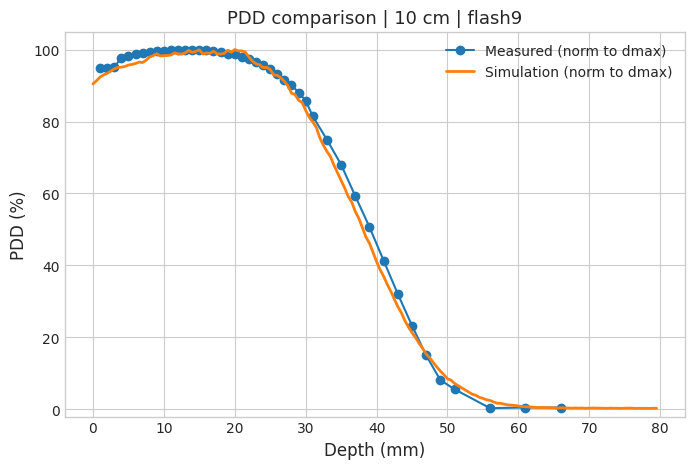

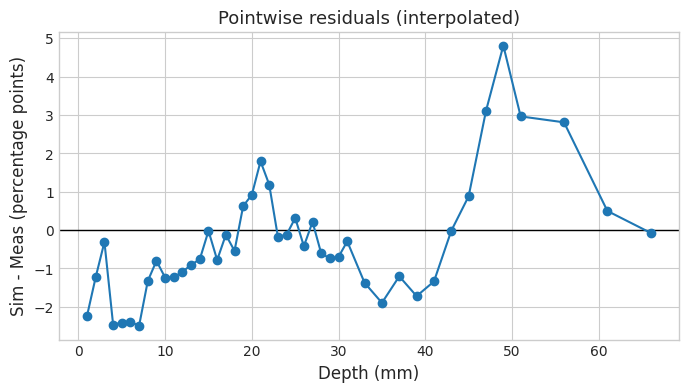

NameError: name 'metrics' is not defined

In [6]:
plt.figure(figsize=(8,5))
plt.plot(meas_df['depth_mm'], meas_norm, 'o-', label='Measured (norm to dmax)')
plt.plot(sim_pdd_df['depth_mm'], sim_norm, '-', lw=2, label='Simulation (norm to dmax)')
plt.xlabel('Depth (mm)')
plt.ylabel('PDD (%)')
plt.title(f'PDD comparison | {applicator_cm} cm | {mode}')
plt.ylim(-2, 105)
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.axhline(0, color='k', lw=1)
plt.plot(comp_df['depth_mm'], comp_df['delta_pctpts'], 'o-')
plt.xlabel('Depth (mm)')
plt.ylabel('Sim - Meas (percentage points)')
plt.title('Pointwise residuals (interpolated)')
plt.show()

pd.DataFrame([metrics])



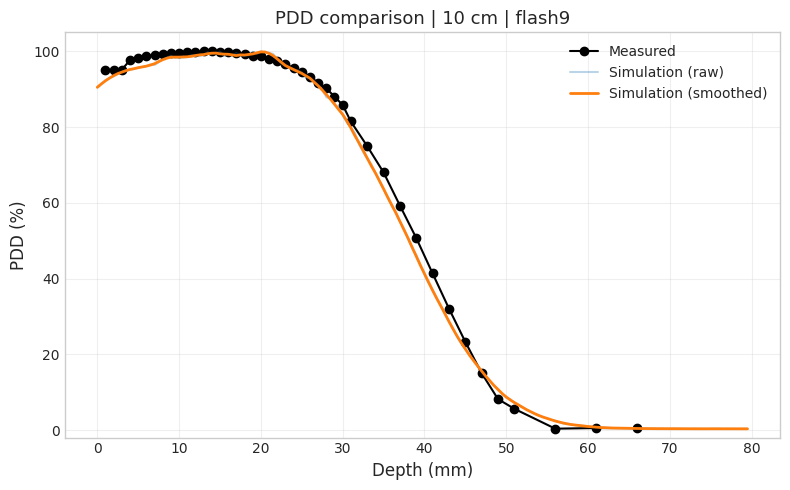

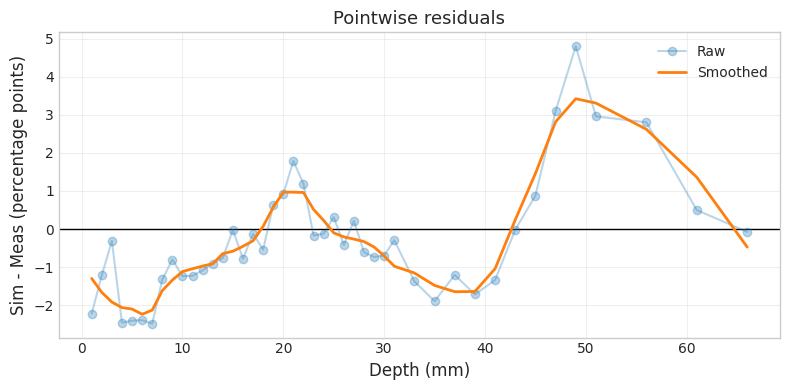

NameError: name 'metrics' is not defined

In [7]:
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------
# LIGHT SMOOTHING SETTINGS
# -------------------------
window = 9   # must be odd (5–9 recommended)
poly = 2

# Apply smoothing ONLY for plotting
sim_norm_smooth = savgol_filter(sim_norm, window_length=window, polyorder=poly)

# For residuals (optional)
delta_smooth = savgol_filter(comp_df['delta_pctpts'], window_length=window, polyorder=poly)

# =========================
# PDD PLOT
# =========================
plt.figure(figsize=(8,5))

# Measured (no smoothing)
plt.plot(meas_df['depth_mm'], meas_norm, 'o-', label='Measured', color='black')

# Raw simulation (faint)
plt.plot(sim_pdd_df['depth_mm'], sim_norm, '-', alpha=0.3, label='Simulation (raw)')

# Smoothed simulation (main curve)
plt.plot(sim_pdd_df['depth_mm'], sim_norm_smooth, '-', lw=2, label='Simulation (smoothed)')

plt.xlabel('Depth (mm)')
plt.ylabel('PDD (%)')
plt.title(f'PDD comparison | {applicator_cm} cm | {mode}')
plt.ylim(-2, 105)
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# RESIDUALS PLOT
# =========================
plt.figure(figsize=(8,4))

plt.axhline(0, color='k', lw=1)

# Raw residuals
plt.plot(comp_df['depth_mm'], comp_df['delta_pctpts'], 'o-', alpha=0.3, label='Raw')

# Smoothed residuals
plt.plot(comp_df['depth_mm'], delta_smooth, '-', lw=2, label='Smoothed')

plt.xlabel('Depth (mm)')
plt.ylabel('Sim - Meas (percentage points)')
plt.title('Pointwise residuals')
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# METRICS TABLE (UNCHANGED)
# =========================
pd.DataFrame([metrics])


## 6) Exit-dose and exit-fluence comparison block

What to compare with:
- **Exit dose profile**: compare against downstream detector dose profile / film / chamber scan at same plane.
- **Exit fluence profile**: compare against fluence-sensitive measurement (e.g., film/scintillator response after correction) or use as a shape diagnostic.

If you have measured exit profiles, place them in files with two columns: `position_mm value`, then set paths below.

In [26]:
xdf = pd.read_excel("build/simsim2.xlsx", sheet_name="flash9")
print(xdf.columns.tolist())

['pos_10cm_dmax', 'dose_10cm_dmax', 'pos_10cm_r50', 'dose_10cm_r50', 'pos_10cm_middepth', 'dose_10cm_middepth', 'pos_5cm_dmax', 'dose_5cm_dmax', 'pos_5cm_r50', 'dose_5cm_r50', 'pos_5cm_middepth', 'dose_5cm_middepth', 'pos_2cm_dmax', 'dose_2cm_dmax', 'pos_2cm_r50', 'dose_2cm_r50', 'pos_2cm_middepth', 'dose_2cm_middepth']


Quick lateral profile summary:


,depth_key,status,meas_center_mm,sim_center_mm,fit_scale,fit_shift_mm,fit_rmse_pctpts,fit_overlap_n,RMSE_pctpts,MAE_pctpts,MaxAbs_pctpts,GammaPassRate_pct
0,dmax,ok,177.048,37.258,11.148,0.0,NaN,0,5.133,3.904,12.407,20.506
1,r50,ok,170.210,37.239,10.965,0.0,NaN,0,3.449,2.655,9.557,25.797
2,middepth,ok,152.263,37.253,8.865,0.0,NaN,0,4.743,3.763,11.314,21.981


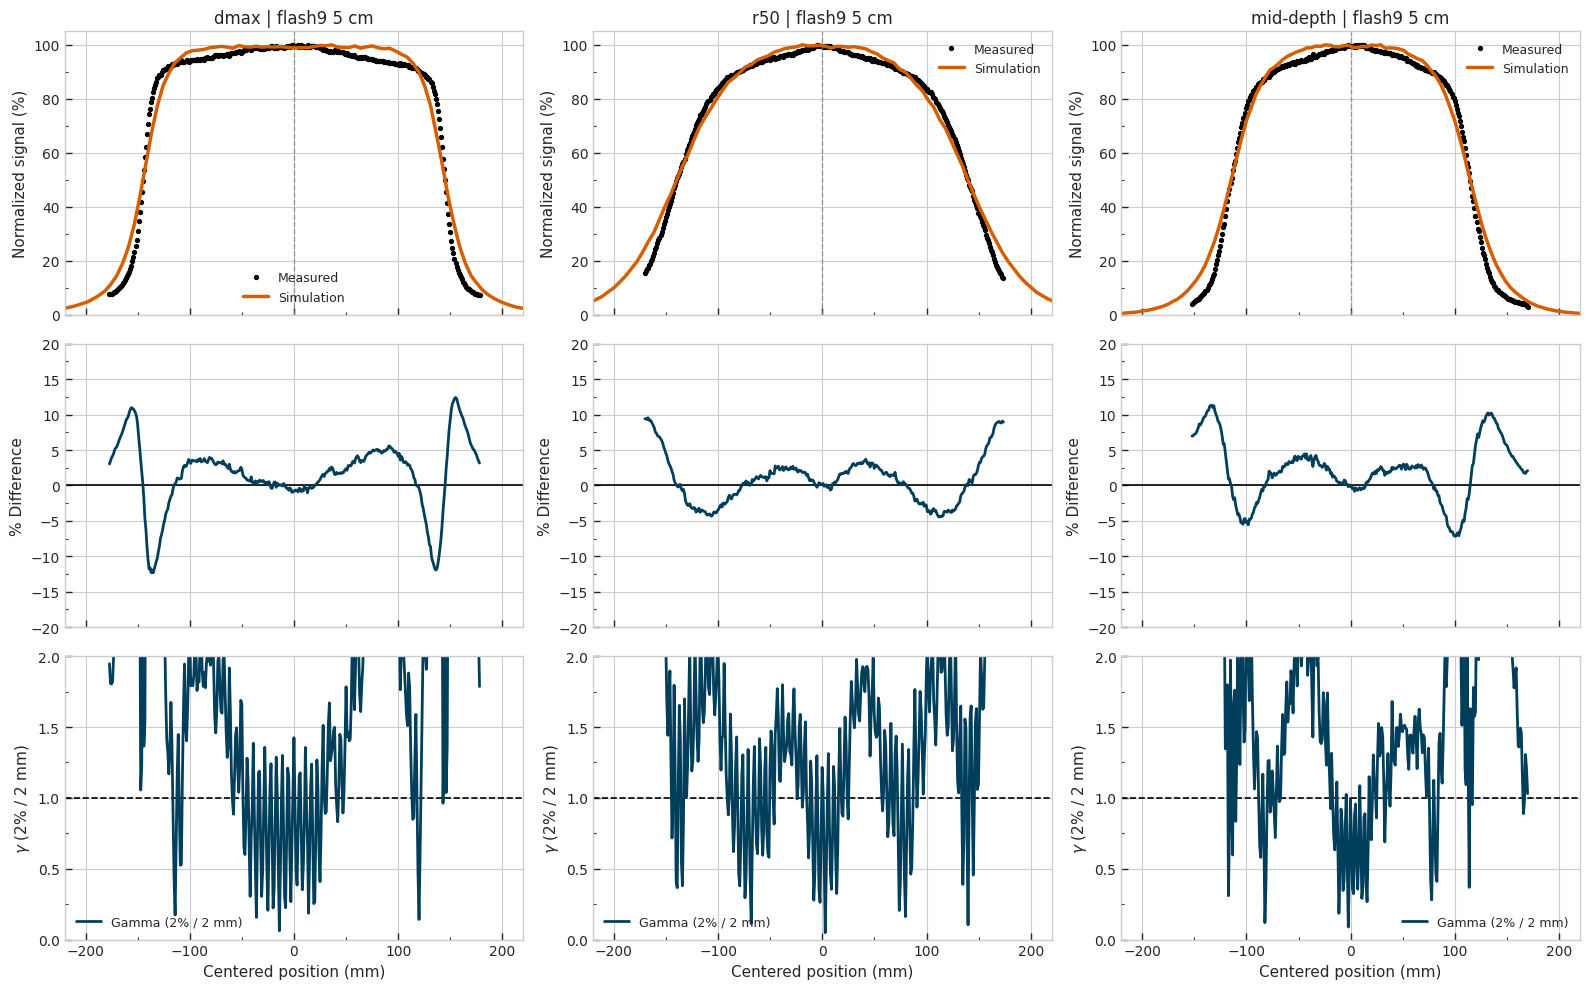

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

# ============================================================
# USER CONTROLS
# ============================================================
lateral_profile_depth_keys = ('dmax', 'r50', 'middepth')

lateral_mode_select = 'flash9'
lateral_applicator_select_cm = 5

# -------------------------
# Measured Excel source
# -------------------------
measured_lateral_excel_file = "build/simsim2.xlsx"
measured_lateral_excel_sheet = "flash9"

measured_lateral_excel_columns = {
    'dmax':     {'pos': 'pos_10cm_dmax',     'dose': 'dose_10cm_dmax'},
    'r50':      {'pos': 'pos_10cm_r50',      'dose': 'dose_10cm_r50'},
    'middepth': {'pos': 'pos_10cm_middepth', 'dose': 'dose_10cm_middepth'},
}

# Optional measured profile files
measured_lateral_files = {
    'dmax': None,
    'r50': None,
    'middepth': None,
}

# Simulated files
sim_lateral_files = {
    'dmax': 'build/latDmax_r1112_E9p70_sE1p30_sTh0p2_N200M_J50026994_T1.txt',
    'r50': 'build/latR50_r1112_E9p70_sE1p30_sTh0p2_N200M_J50026994_T1.txt',
    'middepth': 'build/latMid_r1112_E9p70_sE1p30_sTh0p2_N200M_J50026994_T1.txt',
}

# ============================================================
# FIT / ALIGNMENT CONTROLS
# ============================================================
auto_center_profiles = True

auto_align_by_field_edges = True   # recommended: align source to target using left/right field edges
auto_align_target = 'measured'     # 'measured' => transform sim, 'simulation' => transform measured
auto_edge_level_pct = 50.0         # edge definition level (% of profile max), usually 50 for lateral field width
auto_align_require_valid_edges = True

auto_fit_sim_to_measured = False   # fallback grid fit (used if edge alignment is disabled or fails)
auto_fit_meas_to_sim = False       # fallback grid fit (used if edge alignment is disabled or fails)

# automatic fitting search grids (used only by fallback grid fit)
auto_scale_grid = np.linspace(0.7, 1.4, 281)
auto_shift_grid_mm = np.linspace(-80.0, 80.0, 321)

# ============================================================
# MANUAL SHAPE / POSITION CONTROLS
# Applied AFTER centering
# x_new = x_scale * x_centered + x_shift
# ============================================================
meas_x_scale = {
    'dmax': 1.0,
    'r50': 1.0,
    'middepth': 1.0,
}
meas_x_shift_mm = {
    'dmax': 0.0,
    'r50': 0.0,
    'middepth': 0.0,
}

sim_x_scale = {
    'dmax': 1.0,
    'r50': 1.0,
    'middepth': 1.0,
}
sim_x_shift_mm = {
    'dmax': 0.0,
    'r50': 0.0,
    'middepth': 0.0,
}

# Optional Y scaling / shifting if you want visual shaping too
meas_y_scale = {'dmax': 1.0, 'r50': 1.0, 'middepth': 1.0}
meas_y_shift = {'dmax': 0.0, 'r50': 0.0, 'middepth': 0.0}
sim_y_scale  = {'dmax': 1.0, 'r50': 1.0, 'middepth': 1.0}
sim_y_shift  = {'dmax': 0.0, 'r50': 0.0, 'middepth': 0.0}

# ============================================================
# LOW-DOSE LEG TRIMMING CONTROLS
# Keeps only the central profile between first and last point
# above threshold
# ============================================================
trim_meas_by_threshold = {
    'dmax': False,
    'r50': False,
    'middepth': False,
}

trim_sim_by_threshold = {
    'dmax': False,
    'r50': False,
    'middepth': False,
}

meas_trim_threshold_pct = {
    'dmax': 1.0,
    'r50': 1.0,
    'middepth': 1.0,
}

sim_trim_threshold_pct = {
    'dmax': 1.0,
    'r50': 1.0,
    'middepth': 1.0,
}

# ============================================================
# CROPPING CONTROLS
# Use None to keep full range.
# These are applied AFTER centering and x transform.
# ============================================================
meas_crop_min_mm = {
    'dmax':None,
    'r50': None,
    'middepth': None,
}
meas_crop_max_mm = {
    'dmax': None,
    'r50': None,
    'middepth': None,
}

sim_crop_min_mm = {
    'dmax': None,
    'r50': None,
    'middepth': None,
}
sim_crop_max_mm = {
    'dmax': None,
    'r50': None,
    'middepth': None,
}

# ============================================================
# ANALYSIS / PLOTTING CONTROLS
# ============================================================
gamma_dose_percent = 2.0
gamma_dist_mm = 2.0

profile_smooth_window_mm = 0.0     # set >0 if you want smoothing for display
resid_smooth_window_mm = 0.0
gamma_smooth_window_mm = 0.0

profile_xlim = (-220, 220)         # common x range for all columns
profile_ylim = (0, 105)
resid_ylim = (-20, 20)
gamma_ylim = (0, 2.0)

# appearance
color_meas = '#003f5c'
color_sim = '#D55E00'
color_res = '#003f5c'
color_gamma = '#003f5c'

lw_main = 2.5
lw_secondary = 2.0
lw_ref = 1.2

title_fs = 12
label_fs = 11
tick_fs = 10
legend_fs = 9

# Optional alias
if 'rmax' in measured_lateral_files and measured_lateral_files.get('dmax') is None:
    measured_lateral_files['dmax'] = measured_lateral_files['rmax']
if 'rmax' in sim_lateral_files and sim_lateral_files.get('dmax') is None:
    sim_lateral_files['dmax'] = sim_lateral_files['rmax']

# ============================================================
# HELPERS
# ============================================================
def normalize_profile(y):
    y = np.asarray(y, dtype=float)
    m = np.max(y)
    return 100.0 * y / m if m != 0 else np.zeros_like(y)


def trim_profile_by_threshold(x, y, threshold_pct=5.0):
    """
    Keep only the section from the first to last point where y >= threshold_pct.
    This removes the low-dose 'legs' at both ends.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = y >= threshold_pct
    if np.sum(mask) < 2:
        return x.copy(), y.copy()

    idx = np.where(mask)[0]
    i0 = idx[0]
    i1 = idx[-1]
    return x[i0:i1+1], y[i0:i1+1]

def get_measured_profile_from_excel(excel_file, sheet_name, pos_col, dose_col):
    xdf = pd.read_excel(excel_file, sheet_name=sheet_name)

    if pos_col not in xdf.columns:
        raise KeyError(f"Missing position column: {pos_col}")
    if dose_col not in xdf.columns:
        raise KeyError(f"Missing dose column: {dose_col}")

    out = xdf[[pos_col, dose_col]].copy()
    out.columns = ['position_mm', 'meas']
    out = out.dropna()
    out = out.sort_values('position_mm').drop_duplicates('position_mm').reset_index(drop=True)
    return out

def moving_average_reflect(y, win_pts):
    win_pts = int(max(1, win_pts))
    if win_pts <= 1 or len(y) < 3:
        return np.asarray(y, dtype=float).copy()
    if win_pts % 2 == 0:
        win_pts += 1
    pad = win_pts // 2
    ypad = np.pad(np.asarray(y, dtype=float), (pad, pad), mode='reflect')
    kernel = np.ones(win_pts, dtype=float) / win_pts
    return np.convolve(ypad, kernel, mode='valid')

def smooth_by_mm(x, y, window_mm):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3 or window_mm is None or window_mm <= 0:
        return x.copy(), y.copy()

    dx = np.median(np.diff(x))
    if not np.isfinite(dx) or dx <= 0:
        return x.copy(), y.copy()

    win_pts = max(1, int(round(window_mm / dx)))
    return x.copy(), moving_average_reflect(y, win_pts)

def style_axis(ax, x_major=None, x_minor=None, y_major=None, y_minor=None):
    ax.tick_params(axis='both', which='major', direction='in', length=5, width=1.0, labelsize=tick_fs)
    ax.tick_params(axis='both', which='minor', direction='in', length=2.5, width=0.8)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    if x_major is not None:
        ax.xaxis.set_major_locator(MultipleLocator(x_major))
    if x_minor is not None:
        ax.xaxis.set_minor_locator(MultipleLocator(x_minor))
    else:
        ax.xaxis.set_minor_locator(AutoMinorLocator())

    if y_major is not None:
        ax.yaxis.set_major_locator(MultipleLocator(y_major))
    if y_minor is not None:
        ax.yaxis.set_minor_locator(MultipleLocator(y_minor))
    else:
        ax.yaxis.set_minor_locator(AutoMinorLocator())

def center_profile_on_halfmax_midpoint(x, y):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)

    if len(x) < 3:
        i_max = int(np.argmax(y))
        x0 = float(x[i_max])
        return x - x0, x0

    ymax = np.max(y)
    if ymax <= 0:
        return x.copy(), 0.0

    y_norm = 100.0 * y / ymax
    half = 50.0
    i_peak = int(np.argmax(y_norm))

    x_left = np.nan
    for i in range(i_peak, 0, -1):
        y1, y2 = y_norm[i-1], y_norm[i]
        if (y1 <= half <= y2) or (y2 <= half <= y1):
            x1, x2 = x[i-1], x[i]
            if y2 == y1:
                x_left = x1
            else:
                t = (half - y1) / (y2 - y1)
                x_left = x1 + t * (x2 - x1)
            break

    x_right = np.nan
    for i in range(i_peak, len(y_norm) - 1):
        y1, y2 = y_norm[i], y_norm[i+1]
        if (y1 >= half >= y2) or (y2 >= half >= y1):
            x1, x2 = x[i], x[i+1]
            if y2 == y1:
                x_right = x1
            else:
                t = (half - y1) / (y2 - y1)
                x_right = x1 + t * (x2 - x1)
            break

    if np.isfinite(x_left) and np.isfinite(x_right):
        x0 = 0.5 * (x_left + x_right)
        return x - x0, float(x0)

    i_max = int(np.argmax(y))
    x0 = float(x[i_max])
    return x - x0, x0


def find_profile_edges_at_level(x, y, level_pct=50.0):
    """
    Return left/right x positions where profile crosses level_pct.
    Uses crossing nearest to the peak on each side.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 3:
        return np.nan, np.nan

    ymax = np.max(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan, np.nan

    y_norm = 100.0 * y / ymax
    level = float(level_pct)
    i_peak = int(np.argmax(y_norm))

    x_left = np.nan
    for i in range(i_peak, 0, -1):
        y1, y2 = y_norm[i - 1], y_norm[i]
        if (y1 <= level <= y2) or (y2 <= level <= y1):
            x1, x2 = x[i - 1], x[i]
            if y2 == y1:
                x_left = x1
            else:
                t = (level - y1) / (y2 - y1)
                x_left = x1 + t * (x2 - x1)
            break

    x_right = np.nan
    for i in range(i_peak, len(y_norm) - 1):
        y1, y2 = y_norm[i], y_norm[i + 1]
        if (y1 >= level >= y2) or (y2 >= level >= y1):
            x1, x2 = x[i], x[i + 1]
            if y2 == y1:
                x_right = x1
            else:
                t = (level - y1) / (y2 - y1)
                x_right = x1 + t * (x2 - x1)
            break

    return x_left, x_right


def affine_from_edge_pair(target_edges, source_edges):
    """Compute x' = scale*x + shift from two source edges to two target edges."""
    tL, tR = target_edges
    sL, sR = source_edges

    if not (np.isfinite(tL) and np.isfinite(tR) and np.isfinite(sL) and np.isfinite(sR)):
        return None

    src_w = sR - sL
    tgt_w = tR - tL
    if abs(src_w) < 1e-9:
        return None

    scale = tgt_w / src_w
    shift = tL - scale * sL

    if not np.isfinite(scale) or not np.isfinite(shift) or scale <= 0:
        return None

    return float(scale), float(shift)

def interp_safe(x_src, y_src, x_tgt):
    x_src = np.asarray(x_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    x_tgt = np.asarray(x_tgt, dtype=float)

    y = np.interp(x_tgt, x_src, y_src)
    y[(x_tgt < np.min(x_src)) | (x_tgt > np.max(x_src))] = np.nan
    return y

def crop_xy(x, y, xmin=None, xmax=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.ones_like(x, dtype=bool)
    if xmin is not None:
        mask &= x >= xmin
    if xmax is not None:
        mask &= x <= xmax
    return x[mask], y[mask]

def affine_transform_x(x, scale=1.0, shift=0.0):
    return scale * np.asarray(x, dtype=float) + shift

def affine_transform_y(y, scale=1.0, shift=0.0):
    return scale * np.asarray(y, dtype=float) + shift

def fit_affine_x(target_x, target_y, source_x, source_y,
                 scale_grid, shift_grid, min_overlap_points=20):
    best = {
        'scale': 1.0,
        'shift_mm': 0.0,
        'rmse': np.inf,
        'overlap_n': 0
    }

    for s in scale_grid:
        xs = s * source_x
        for sh in shift_grid:
            xs_fit = xs + sh
            src_on_tgt = interp_safe(xs_fit, source_y, target_x)
            valid = np.isfinite(src_on_tgt) & np.isfinite(target_y)
            n_valid = int(np.sum(valid))
            if n_valid < min_overlap_points:
                continue
            rmse = float(np.sqrt(np.mean((src_on_tgt[valid] - target_y[valid]) ** 2)))
            if rmse < best['rmse']:
                best = {
                    'scale': float(s),
                    'shift_mm': float(sh),
                    'rmse': rmse,
                    'overlap_n': n_valid
                }
    return best

def gamma_1d(meas_x, meas_y, sim_x, sim_y, dose_crit=2.0, dist_crit=2.0):
    gamma_vals = np.full_like(meas_x, np.nan, dtype=float)
    for i, (xm, ym) in enumerate(zip(meas_x, meas_y)):
        dist_term = ((sim_x - xm) / dist_crit) ** 2
        dose_term = ((sim_y - ym) / dose_crit) ** 2
        gamma_vals[i] = np.sqrt(np.min(dist_term + dose_term))
    return gamma_vals

# ============================================================
# LOAD / ANALYZE ALL THREE DEPTHS
# ============================================================
results = {}
summary_rows = []

for key in lateral_profile_depth_keys:
    sfile = sim_lateral_files.get(key)
    mfile = measured_lateral_files.get(key)

    if not sfile:
        summary_rows.append({'depth_key': key, 'status': 'missing_sim_file'})
        continue

    # ----- read sim
    sdf = read_profile_file(
        sfile,
        y_name='sim',
        position_axis=profile_axis,
        position_bin_mm=profile_position_bin_mm,
        position_offset_mm=profile_position_offset_mm
    ).copy()

    sim_x_raw = sdf['position_mm'].values * sim_position_scale + sim_position_shift_mm
    sim_y_raw = sdf['sim'].values

    # ----- read measured
    if mfile:
        mdf = read_profile_file(
            mfile,
            y_name='meas',
            position_axis=profile_axis,
            position_bin_mm=profile_position_bin_mm,
            position_offset_mm=profile_position_offset_mm
        ).copy()
    else:
        cols = measured_lateral_excel_columns.get(key)
        if cols is None:
            summary_rows.append({'depth_key': key, 'status': 'missing_measured'})
            continue
        mdf = get_measured_profile_from_excel(
            measured_lateral_excel_file,
            measured_lateral_excel_sheet,
            cols['pos'],
            cols['dose']
        )

    meas_x_raw = mdf['position_mm'].values
    meas_y_raw = mdf['meas'].values

    # ----- normalize
    sim_y_norm = normalize_profile(sim_y_raw)
    meas_y_norm = normalize_profile(meas_y_raw)

    # ----- initial center
    if auto_center_profiles:
        sim_x_ctr, sim_center_mm = center_profile_on_halfmax_midpoint(sim_x_raw, sim_y_raw)
        meas_x_ctr, meas_center_mm = center_profile_on_halfmax_midpoint(meas_x_raw, meas_y_raw)
    else:
        sim_x_ctr, sim_center_mm = sim_x_raw.copy(), 0.0
        meas_x_ctr, meas_center_mm = meas_x_raw.copy(), 0.0

    # ----- manual x/y transforms
    sim_x_mod = affine_transform_x(sim_x_ctr, sim_x_scale[key], sim_x_shift_mm[key])
    meas_x_mod = affine_transform_x(meas_x_ctr, meas_x_scale[key], meas_x_shift_mm[key])

    sim_y_mod = affine_transform_y(sim_y_norm, sim_y_scale[key], sim_y_shift[key])
    meas_y_mod = affine_transform_y(meas_y_norm, meas_y_scale[key], meas_y_shift[key])

    # clip y to sensible bounds
    sim_y_mod = np.clip(sim_y_mod, 0, 100)
    meas_y_mod = np.clip(meas_y_mod, 0, 100)

    # ----- trim low-dose legs first
    if trim_meas_by_threshold[key]:
        meas_x_mod, meas_y_mod = trim_profile_by_threshold(
            meas_x_mod, meas_y_mod, meas_trim_threshold_pct[key]
        )

    if trim_sim_by_threshold[key]:
        sim_x_mod, sim_y_mod = trim_profile_by_threshold(
            sim_x_mod, sim_y_mod, sim_trim_threshold_pct[key]
        )

    # ----- then apply any explicit x cropping if wanted
    sim_x_mod, sim_y_mod = crop_xy(
        sim_x_mod, sim_y_mod,
        sim_crop_min_mm[key], sim_crop_max_mm[key]
    )
    meas_x_mod, meas_y_mod = crop_xy(
        meas_x_mod, meas_y_mod,
        meas_crop_min_mm[key], meas_crop_max_mm[key]
    )

    # ----- optional automatic affine fit
    fit_scale = 1.0
    fit_shift = 0.0
    fit_rmse = np.nan
    fit_overlap_n = 0

    # Preferred: edge-based alignment so left/right profile edges start/end together.
    edge_fit_applied = False
    if auto_align_by_field_edges:
        meas_edges = find_profile_edges_at_level(meas_x_mod, meas_y_mod, auto_edge_level_pct)
        sim_edges = find_profile_edges_at_level(sim_x_mod, sim_y_mod, auto_edge_level_pct)

        if auto_align_target == 'simulation':
            affine = affine_from_edge_pair(sim_edges, meas_edges)
            if affine is not None:
                s, sh = affine
                meas_x_mod = s * meas_x_mod + sh
                fit_scale = s
                fit_shift = sh
                edge_fit_applied = True
        else:
            affine = affine_from_edge_pair(meas_edges, sim_edges)
            if affine is not None:
                s, sh = affine
                sim_x_mod = s * sim_x_mod + sh
                fit_scale = s
                fit_shift = sh
                edge_fit_applied = True

        if auto_align_require_valid_edges and not edge_fit_applied:
            print(f"[{key}] edge alignment skipped: could not determine valid left/right edges at {auto_edge_level_pct}%")

    # Fallback: brute-force grid fit if requested and edge fit was not applied.
    if (not edge_fit_applied) and auto_fit_sim_to_measured:
        fit = fit_affine_x(
            target_x=meas_x_mod,
            target_y=meas_y_mod,
            source_x=sim_x_mod,
            source_y=sim_y_mod,
            scale_grid=auto_scale_grid,
            shift_grid=auto_shift_grid_mm,
            min_overlap_points=20
        )
        sim_x_mod = fit['scale'] * sim_x_mod + fit['shift_mm']
        fit_scale = fit['scale']
        fit_shift = fit['shift_mm']
        fit_rmse = fit['rmse']
        fit_overlap_n = fit['overlap_n']

    elif (not edge_fit_applied) and auto_fit_meas_to_sim:
        fit = fit_affine_x(
            target_x=sim_x_mod,
            target_y=sim_y_mod,
            source_x=meas_x_mod,
            source_y=meas_y_mod,
            scale_grid=auto_scale_grid,
            shift_grid=auto_shift_grid_mm,
            min_overlap_points=20
        )
        meas_x_mod = fit['scale'] * meas_x_mod + fit['shift_mm']
        fit_scale = fit['scale']
        fit_shift = fit['shift_mm']
        fit_rmse = fit['rmse']
        fit_overlap_n = fit['overlap_n']


    # ----- optional smoothing
    if profile_smooth_window_mm and profile_smooth_window_mm > 0:
        meas_x_plot, meas_y_plot = smooth_by_mm(meas_x_mod, meas_y_mod, profile_smooth_window_mm)
        sim_x_plot, sim_y_plot = smooth_by_mm(sim_x_mod, sim_y_mod, profile_smooth_window_mm)
    else:
        meas_x_plot, meas_y_plot = meas_x_mod.copy(), meas_y_mod.copy()
        sim_x_plot, sim_y_plot = sim_x_mod.copy(), sim_y_mod.copy()

    # ----- compare on measured x grid
    sim_on_meas = interp_safe(sim_x_plot, sim_y_plot, meas_x_plot)
    comp = pd.DataFrame({
        'x_mm': meas_x_plot,
        'measured_pct': meas_y_plot,
        'sim_pct': sim_on_meas
    })
    comp = comp[np.isfinite(comp['sim_pct'])].copy()
    comp['delta_pctpts'] = comp['sim_pct'] - comp['measured_pct']

    # ----- gamma
    gamma_vals = gamma_1d(
        comp['x_mm'].values,
        comp['measured_pct'].values,
        sim_x_plot,
        sim_y_plot,
        dose_crit=gamma_dose_percent,
        dist_crit=gamma_dist_mm
    )
    gamma_pass_rate = 100.0 * np.mean(gamma_vals <= 1.0) if len(gamma_vals) else np.nan

    # ----- optional smoothing for residuals/gamma
    x_res = comp['x_mm'].values
    y_res = comp['delta_pctpts'].values
    if resid_smooth_window_mm and resid_smooth_window_mm > 0:
        x_res, y_res = smooth_by_mm(x_res, y_res, resid_smooth_window_mm)

    x_gam = comp['x_mm'].values
    y_gam = gamma_vals
    if gamma_smooth_window_mm and gamma_smooth_window_mm > 0:
        x_gam, y_gam = smooth_by_mm(x_gam, y_gam, gamma_smooth_window_mm)

    results[key] = {
        'meas_x': meas_x_plot,
        'meas_y': meas_y_plot,
        'sim_x': sim_x_plot,
        'sim_y': sim_y_plot,
        'comp': comp,
        'res_x': x_res,
        'res_y': y_res,
        'gamma_x': x_gam,
        'gamma_y': y_gam,
        'meas_center_mm': meas_center_mm,
        'sim_center_mm': sim_center_mm,
        'fit_scale': fit_scale,
        'fit_shift_mm': fit_shift,
        'fit_rmse_pctpts': fit_rmse,
        'fit_overlap_n': fit_overlap_n,
        'RMSE_pctpts': float(np.sqrt(np.mean(comp['delta_pctpts']**2))),
        'MAE_pctpts': float(np.mean(np.abs(comp['delta_pctpts']))),
        'MaxAbs_pctpts': float(np.max(np.abs(comp['delta_pctpts']))),
        'GammaPassRate_pct': gamma_pass_rate,
    }

    summary_rows.append({
        'depth_key': key,
        'status': 'ok',
        'meas_center_mm': float(meas_center_mm),
        'sim_center_mm': float(sim_center_mm),
        'fit_scale': float(fit_scale),
        'fit_shift_mm': float(fit_shift),
        'fit_rmse_pctpts': float(fit_rmse) if np.isfinite(fit_rmse) else np.nan,
        'fit_overlap_n': int(fit_overlap_n),
        'RMSE_pctpts': results[key]['RMSE_pctpts'],
        'MAE_pctpts': results[key]['MAE_pctpts'],
        'MaxAbs_pctpts': results[key]['MaxAbs_pctpts'],
        'GammaPassRate_pct': gamma_pass_rate,
    })

# ============================================================
# SUMMARY TABLE
# ============================================================
quick_profile_summary_df = pd.DataFrame(summary_rows)
print('Quick lateral profile summary:')
display(quick_profile_summary_df.round(3))

# ============================================================
# MULTI-PANEL FIGURE: 3 columns × 3 rows
# top = profile, middle = % difference, bottom = gamma
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex='col')
fig.subplots_adjust(wspace=0.22, hspace=0.18)

pretty_names = {
    'dmax': 'dmax',
    'r50': 'r50',
    'middepth': 'mid-depth'
}

for col, key in enumerate(lateral_profile_depth_keys):
    ax_top = axes[0, col]
    ax_mid = axes[1, col]
    ax_bot = axes[2, col]

    if key not in results:
        ax_top.set_visible(False)
        ax_mid.set_visible(False)
        ax_bot.set_visible(False)
        continue

    r = results[key]

    # ----- top: profile overlay
    ax_top.plot(r['meas_x'], r['meas_y'], 'o', ms=2.8, color='black', label='Measured')
    ax_top.plot(r['sim_x'], r['sim_y'], '-', lw=lw_main, color=color_sim, label='Simulation')
    ax_top.axvline(0, color='gray', lw=1.0, ls='--', alpha=0.7)
    ax_top.set_title(f"{pretty_names[key]} | {lateral_mode_select} {lateral_applicator_select_cm} cm", fontsize=title_fs)
    ax_top.set_ylabel('Normalized signal (%)', fontsize=label_fs)
    ax_top.set_xlim(*profile_xlim)
    ax_top.set_ylim(*profile_ylim)
    style_axis(ax_top, x_major=100, x_minor=50, y_major=20, y_minor=10)
    ax_top.legend(frameon=False, fontsize=legend_fs, loc='best')

    # ----- middle: % difference
    ax_mid.axhline(0, color='black', lw=lw_ref)
    ax_mid.plot(r['res_x'], r['res_y'], '-', lw=lw_secondary, color=color_res)
    ax_mid.set_ylabel('% Difference', fontsize=label_fs)
    ax_mid.set_xlim(*profile_xlim)
    ax_mid.set_ylim(*resid_ylim)
    style_axis(ax_mid, x_major=100, x_minor=50, y_major=5, y_minor=2.5)

    # ----- bottom: gamma
    ax_bot.axhline(1.0, color='black', lw=lw_ref, ls='--')
    ax_bot.plot(r['gamma_x'], r['gamma_y'], '-', lw=lw_secondary, color=color_gamma, label='Gamma (2% / 2 mm)')
    ax_bot.set_xlabel('Centered position (mm)', fontsize=label_fs)
    ax_bot.set_ylabel(r'$\gamma$ (2% / 2 mm)', fontsize=label_fs)
    ax_bot.set_xlim(*profile_xlim)
    ax_bot.set_ylim(*gamma_ylim)
    style_axis(ax_bot, x_major=100, x_minor=50, y_major=0.5, y_minor=0.25)
    ax_bot.legend(frameon=False, fontsize=legend_fs, loc='best')

plt.tight_layout()
plt.show()

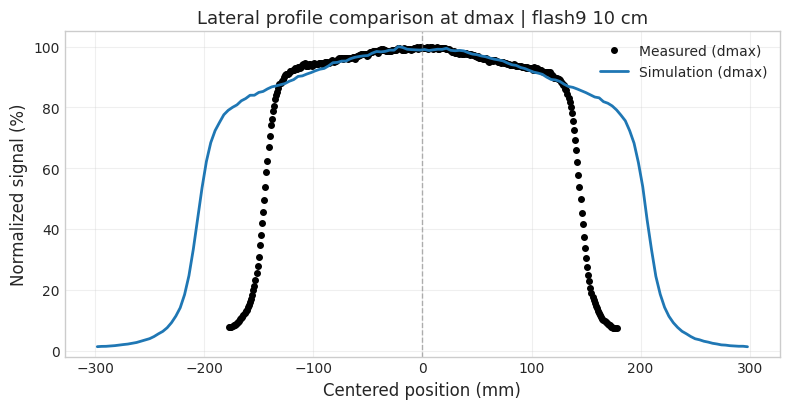

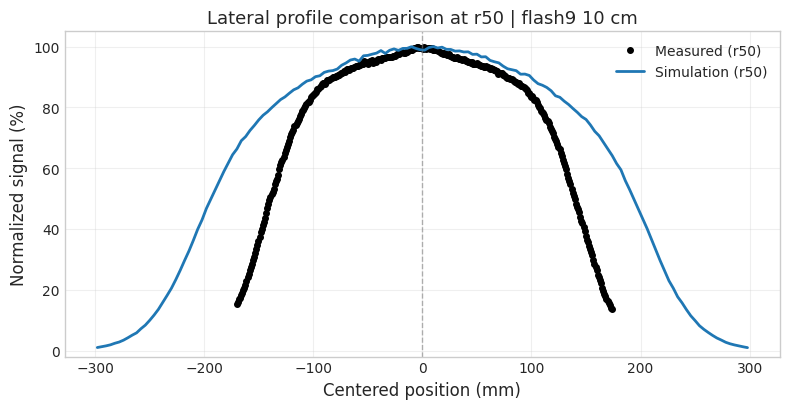

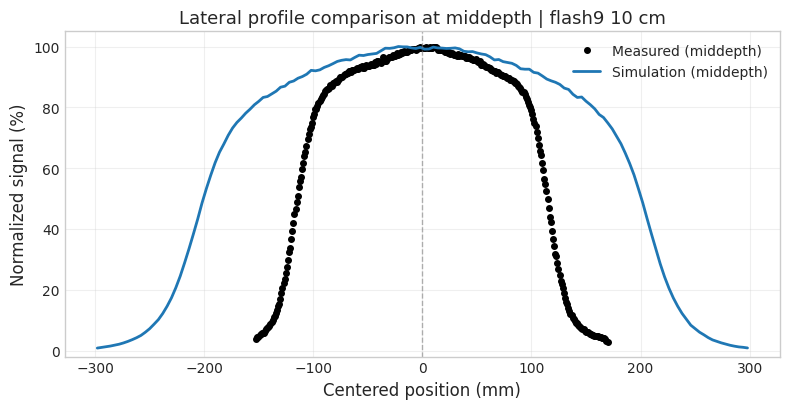

Quick lateral profile summary:


,depth_key,status,meas_center_mm,sim_center_mm,RMSE_pctpts,MAE_pctpts,MaxAbs_pctpts
0,dmax,ok,177.048,298.017,28.816,13.820,72.791
1,r50,ok,170.210,297.940,20.500,12.967,50.865
2,middepth,ok,152.263,298.002,38.153,24.443,77.527


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Lateral profile comparison setup (dmax/r50/middepth)

lateral_profile_depth_keys = ('dmax', 'r50', 'middepth')

lateral_mode_select = 'flash9'
lateral_applicator_select_cm = 10

# -------------------------
# Measured Excel source
# -------------------------
measured_lateral_excel_file = "build/simsim2.xlsx"
measured_lateral_excel_sheet = "flash9"

measured_lateral_excel_columns = {
    'dmax':     {'pos': 'pos_10cm_dmax',     'dose': 'dose_10cm_dmax'},
    'r50':      {'pos': 'pos_10cm_r50',      'dose': 'dose_10cm_r50'},
    'middepth': {'pos': 'pos_10cm_middepth', 'dose': 'dose_10cm_middepth'},
}

# Optional measured profile files
measured_lateral_files = {
    'dmax': None,
    'r50': None,
    'middepth': None,
}

# Simulated files
sim_lateral_files = {
    'dmax': 'build/latDmax_r1119_E9p70_sE1p30_sTh0p2_N400M_J50027333_T1.txt',
    'r50': 'build/latR50_r1119_E9p70_sE1p30_sTh0p2_N400M_J50027333_T1.txt',
    'middepth': 'build/latMid_r1119_E9p70_sE1p30_sTh0p2_N400M_J50027333_T1.txt',
}

# -------------------------
# Alignment controls
# -------------------------
align_profiles_to_center = True

# Optional extra correction to simulated x-axis
# Use these if the sim profile still looks too narrow/wide after centering
sim_profile_x_scale = 8
sim_profile_x_shift_mm = 0.0

# Optional extra correction to measured x-axis
meas_profile_x_scale = 1.0
meas_profile_x_shift_mm = 0.0

# Optional alias
if 'rmax' in measured_lateral_files and measured_lateral_files.get('dmax') is None:
    measured_lateral_files['dmax'] = measured_lateral_files['rmax']
if 'rmax' in sim_lateral_files and sim_lateral_files.get('dmax') is None:
    sim_lateral_files['dmax'] = sim_lateral_files['rmax']


def normalize_profile(y):
    m = np.max(y)
    return 100.0 * y / m if m != 0 else np.zeros_like(y)


def get_measured_profile_from_excel(excel_file, sheet_name, pos_col, dose_col):
    xdf = pd.read_excel(excel_file, sheet_name=sheet_name)

    if pos_col not in xdf.columns:
        raise KeyError(f"Missing position column: {pos_col}")
    if dose_col not in xdf.columns:
        raise KeyError(f"Missing dose column: {dose_col}")

    out = xdf[[pos_col, dose_col]].copy()
    out.columns = ['position_mm', 'meas']
    out = out.dropna()
    out = out.sort_values('position_mm').drop_duplicates('position_mm').reset_index(drop=True)
    return out


def center_profile_on_peak(x, y):
    """Shift profile so the maximum is at x=0."""
    i_max = int(np.argmax(y))
    x0 = float(x[i_max])
    return x - x0, x0


def center_profile_on_halfmax_midpoint(x, y):
    """
    More robust centering for flat-top profiles:
    find left/right 50% crossings and center their midpoint at 0.
    Falls back to peak centering if crossings are not found.
    """
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)

    if len(x) < 3:
        return center_profile_on_peak(x, y)

    ymax = np.max(y)
    if ymax <= 0:
        return x.copy(), 0.0

    y_norm = 100.0 * y / ymax
    half = 50.0
    i_peak = int(np.argmax(y_norm))

    # left crossing
    x_left = np.nan
    for i in range(i_peak, 0, -1):
        y1, y2 = y_norm[i-1], y_norm[i]
        if (y1 <= half <= y2) or (y2 <= half <= y1):
            x1, x2 = x[i-1], x[i]
            if y2 == y1:
                x_left = x1
            else:
                t = (half - y1) / (y2 - y1)
                x_left = x1 + t * (x2 - x1)
            break

    # right crossing
    x_right = np.nan
    for i in range(i_peak, len(y_norm)-1):
        y1, y2 = y_norm[i], y_norm[i+1]
        if (y1 >= half >= y2) or (y2 >= half >= y1):
            x1, x2 = x[i], x[i+1]
            if y2 == y1:
                x_right = x1
            else:
                t = (half - y1) / (y2 - y1)
                x_right = x1 + t * (x2 - x1)
            break

    if np.isfinite(x_left) and np.isfinite(x_right):
        x0 = 0.5 * (x_left + x_right)
        return x - x0, float(x0)

    return center_profile_on_peak(x, y)


quick_profile_rows = []

for key in lateral_profile_depth_keys:
    sfile = sim_lateral_files.get(key)
    mfile = measured_lateral_files.get(key)

    if not sfile:
        quick_profile_rows.append({'depth_key': key, 'status': 'missing_sim_file'})
        continue

    # -------------------------
    # Read simulated profile
    # -------------------------
    sdf = read_profile_file(
        sfile,
        y_name='sim',
        position_axis=profile_axis,
        position_bin_mm=profile_position_bin_mm,
        position_offset_mm=profile_position_offset_mm
    ).copy()

    sdf['position_mm'] = sdf['position_mm'] * sim_position_scale + sim_position_shift_mm
    sdf['position_mm'] = sdf['position_mm'] * sim_profile_x_scale + sim_profile_x_shift_mm

    sim_y_raw = sdf['sim'].values
    sim_x = sdf['position_mm'].values

    # -------------------------
    # Read measured profile
    # -------------------------
    if mfile:
        mdf = read_profile_file(
            mfile,
            y_name='meas',
            position_axis=profile_axis,
            position_bin_mm=profile_position_bin_mm,
            position_offset_mm=profile_position_offset_mm
        ).copy()
    else:
        cols = measured_lateral_excel_columns.get(key)
        if cols is None:
            mdf = None
        else:
            mdf = get_measured_profile_from_excel(
                measured_lateral_excel_file,
                measured_lateral_excel_sheet,
                cols['pos'],
                cols['dose']
            )

    if mdf is None:
        sim_prof = normalize_profile(sim_y_raw)
        plt.figure(figsize=(8, 4.2))
        plt.plot(sim_x, sim_prof, '-', lw=2, label=f'Simulation ({key})', color='tab:blue')
        plt.title(f'Lateral profile (simulation only) at {key}')
        plt.xlabel('Position (mm)')
        plt.ylabel('Normalized signal (%)')
        plt.ylim(-2, 105)
        plt.grid(True, alpha=0.3)
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

        quick_profile_rows.append({
            'depth_key': key,
            'status': 'sim_only',
            'RMSE_pctpts': np.nan,
            'MAE_pctpts': np.nan,
            'MaxAbs_pctpts': np.nan
        })
        continue

    mdf = mdf.copy()
    mdf['position_mm'] = mdf['position_mm'] * meas_profile_x_scale + meas_profile_x_shift_mm

    meas_x = mdf['position_mm'].values
    meas_y_raw = mdf['meas'].values

    # -------------------------
    # Align both to center
    # -------------------------
    if align_profiles_to_center:
        # for broad flat-top fields, half-max midpoint is better than peak index
        sim_x_aligned, sim_center_mm = center_profile_on_halfmax_midpoint(sim_x, sim_y_raw)
        meas_x_aligned, meas_center_mm = center_profile_on_halfmax_midpoint(meas_x, meas_y_raw)
    else:
        sim_x_aligned, sim_center_mm = sim_x.copy(), 0.0
        meas_x_aligned, meas_center_mm = meas_x.copy(), 0.0

    sim_prof = normalize_profile(sim_y_raw)
    meas_prof = normalize_profile(meas_y_raw)

    # interpolate simulation onto measured positions
    sim_interp = np.interp(meas_x_aligned, sim_x_aligned, sim_prof)

    comp = pd.DataFrame({
        'x_mm': meas_x_aligned,
        'measured_pct': meas_prof,
        'sim_pct': sim_interp
    })
    comp['delta_pctpts'] = comp['sim_pct'] - comp['measured_pct']

    plt.figure(figsize=(8, 4.2))
    plt.plot(meas_x_aligned, meas_prof, 'o', ms=4, label=f'Measured ({key})', color='black')
    plt.plot(sim_x_aligned, sim_prof, '-', lw=2, label=f'Simulation ({key})', color='tab:blue')
    plt.axvline(0, color='gray', lw=1, ls='--', alpha=0.6)
    plt.title(f'Lateral profile comparison at {key} | {lateral_mode_select} {lateral_applicator_select_cm} cm')
    plt.xlabel('Centered position (mm)')
    plt.ylabel('Normalized signal (%)')
    plt.ylim(-2, 105)
    plt.grid(True, alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    quick_profile_rows.append({
        'depth_key': key,
        'status': 'ok',
        'meas_center_mm': float(meas_center_mm),
        'sim_center_mm': float(sim_center_mm),
        'RMSE_pctpts': float(np.sqrt(np.mean(comp['delta_pctpts']**2))),
        'MAE_pctpts': float(np.mean(np.abs(comp['delta_pctpts']))),
        'MaxAbs_pctpts': float(np.max(np.abs(comp['delta_pctpts']))),
    })

quick_profile_summary_df = pd.DataFrame(quick_profile_rows)
print('Quick lateral profile summary:')
display(quick_profile_summary_df.round(3))


## 7) Parameter-tuning guidance block (how to make simulated PDD fit measured)

This block gives **data-driven hints** on which beam/source parameters are likely off.

In [176]:
def suggest_source_tuning(metrics_dict):
    suggestions = []
    dmax_shift = metrics_dict['dmax_shift_mm(sim-meas)']
    sim_r50 = metrics_dict['sim_R50_mm']
    meas_r50 = metrics_dict['meas_R50_mm']

    if np.isfinite(dmax_shift):
        if dmax_shift > 1.0:
            suggestions.append('Simulated dmax is too deep -> decrease mean beam energy slightly.')
        elif dmax_shift < -1.0:
            suggestions.append('Simulated dmax is too shallow -> increase mean beam energy slightly.')

    if np.isfinite(sim_r50) and np.isfinite(meas_r50):
        dr50 = sim_r50 - meas_r50
        if dr50 > 1.5:
            suggestions.append('R50 too deep in simulation -> reduce mean energy or add low-energy tail filtering.')
        elif dr50 < -1.5:
            suggestions.append('R50 too shallow in simulation -> increase mean energy or reduce energy spread.')

    mae = metrics_dict['MAE_pctpts']
    if mae > 4:
        suggestions.append('Overall shape mismatch is large -> tune source angular spread and spot size (scatter conditions).')

    surface_sim = comp_df.loc[comp_df['depth_mm'].idxmin(), 'sim_norm_pct_interp']
    surface_meas = comp_df.loc[comp_df['depth_mm'].idxmin(), 'measured_norm_pct']
    if surface_sim - surface_meas > 2:
        suggestions.append('Surface dose too high in simulation -> narrow angular spread or refine upstream material model.')
    elif surface_sim - surface_meas < -2:
        suggestions.append('Surface dose too low in simulation -> slightly broaden angular spread / include additional scatter.')

    if not suggestions:
        suggestions.append('Fit is already reasonably close. Next: fine-scan mean energy in small steps and minimize RMSE.')

    return suggestions


tuning_suggestions = suggest_source_tuning(metrics)
print('Suggested beam/source adjustments:')
for i, s in enumerate(tuning_suggestions, 1):
    print(f'{i}. {s}')




Suggested beam/source adjustments:
1. Surface dose too low in simulation -> slightly broaden angular spread / include additional scatter.


## 8) Optional mini grid-search template (offline workflow)

Use this table to track reruns when you change source parameters in Geant4 macro files.

In [177]:
run_log = pd.DataFrame(columns=[
    'run_id', 'mean_energy_MeV', 'energy_sigma_MeV', 'spot_sigma_mm', 'ang_sigma_deg',
    'dmax_shift_mm', 'R50_shift_mm', 'RMSE_pctpts', 'MAE_pctpts'
])
run_log



,run_id,mean_energy_MeV,energy_sigma_MeV,spot_sigma_mm,ang_sigma_deg,dmax_shift_mm,R50_shift_mm,RMSE_pctpts,MAE_pctpts


## 9) Publication-grade PDD comparison block

Use this block for figures/tables suitable for manuscript supplements/results:
- Overlay plot with clear styling.
- Residual panel (Sim - Meas).
- Physics parameter table (`dmax`, `R90`, `R80`, `R50`, `R20`, `Rp`).
- Summary agreement metrics (MAE/RMSE/MaxAbs and distal-tail MAE).

/tmp/ipykernel_3953082/1693275524.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


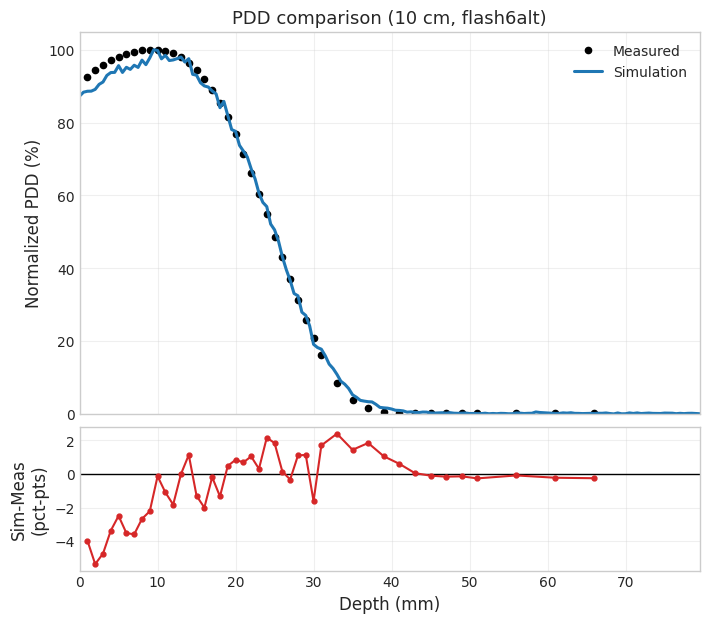

Physics PDD parameter comparison:


,Measured,Simulation,Sim-Meas
dmax_mm,9.000,9.750,0.750
R90_mm,16.652,16.122,-0.530
R80_mm,19.314,19.254,-0.059
R50_mm,24.789,25.094,0.304
R20_mm,30.161,29.914,-0.247
Rp_est_mm,27.768,28.103,0.335


Agreement metrics:


,MAE_pctpts,RMSE_pctpts,MaxAbs_pctpts,Tail_MAE_pctpts(<=20%)
0,1.435,1.953,5.376,0.739


In [178]:
# ---------- Publication-grade comparison settings ----------
pub_title = f'PDD comparison ({applicator_cm} cm, {mode})'
pub_xlim = (0, max(meas_df['depth_mm'].max(), sim_pdd_df['depth_mm'].max()))
pub_ylim = (0, 105)
percent_window_for_tail = 20  # define distal-tail as <= 20% region


def pdd_metrics_full(depth_mm, pdd_norm, use_robust_dmax=False):
    dmax = robust_dmax(depth_mm, pdd_norm) if use_robust_dmax else float(depth_mm[np.argmax(pdd_norm)])
    r90 = float(find_depth_at_percent(depth_mm, pdd_norm, 90))
    r80 = float(find_depth_at_percent(depth_mm, pdd_norm, 80))
    r50 = float(find_depth_at_percent(depth_mm, pdd_norm, 50))
    r20 = float(find_depth_at_percent(depth_mm, pdd_norm, 20))
    # Practical range (common approximation using linear relation from R50)
    rp = 1.10 * r50 + 0.5 if np.isfinite(r50) else np.nan
    return {
        'dmax_mm': dmax,
        'R90_mm': r90,
        'R80_mm': r80,
        'R50_mm': r50,
        'R20_mm': r20,
        'Rp_est_mm': float(rp),
    }


def agreement_summary(comp):
    out = {
        'MAE_pctpts': float(comp['abs_delta_pctpts'].mean()),
        'RMSE_pctpts': float(np.sqrt(np.mean(comp['delta_pctpts']**2))),
        'MaxAbs_pctpts': float(comp['abs_delta_pctpts'].max()),
    }
    tail = comp[comp['measured_norm_pct'] <= percent_window_for_tail]
    out['Tail_MAE_pctpts(<=20%)'] = float(tail['abs_delta_pctpts'].mean()) if len(tail) else np.nan
    return out


# Metrics tables
meas_phys = pdd_metrics_full(meas_df['depth_mm'].values, meas_norm, use_robust_dmax=False)
sim_phys = pdd_metrics_full(sim_pdd_df['depth_mm'].values, sim_norm, use_robust_dmax=True)
phys_table = pd.DataFrame({'Measured': meas_phys, 'Simulation': sim_phys})
phys_table['Sim-Meas'] = phys_table['Simulation'] - phys_table['Measured']

agree = agreement_summary(comp_df)
agree_table = pd.DataFrame([agree])

# Figure: overlay + residuals
fig, axes = plt.subplots(
    2, 1,
    figsize=(8, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [3.2, 1.2], 'hspace': 0.05}
)

ax = axes[0]
ax.plot(meas_df['depth_mm'], meas_norm, 'o', ms=4.5, label='Measured', color='black')
ax.plot(sim_pdd_df['depth_mm'], sim_norm, '-', lw=2.2, label='Simulation', color='tab:blue')
ax.set_ylabel('Normalized PDD (%)')
ax.set_xlim(*pub_xlim)
ax.set_ylim(*pub_ylim)
ax.set_title(pub_title)
ax.legend(frameon=False, loc='best')
ax.grid(True, alpha=0.3)

axr = axes[1]
axr.axhline(0, color='k', lw=1)
axr.plot(comp_df['depth_mm'], comp_df['delta_pctpts'], 'o-', ms=3.5, lw=1.5, color='tab:red')
axr.set_xlabel('Depth (mm)')
axr.set_ylabel('Sim-Meas\n(pct-pts)')
axr.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Physics PDD parameter comparison:')
display(phys_table.round(3))
print('Agreement metrics:')
display(agree_table.round(3))




## 10) Multi-file matcher: find which simulated PDD txt matches measurement best

This block scans many `pdd*.txt` simulation files, compares each to the selected measured dataset, and ranks candidates by:
1. **Curve agreement** (RMSE/MAE/MaxAbs).
2. **Physics-parameter agreement** (`dmax`, `R90`, `R80`, `R50`, `R20`, `Rp`).

Use this when you have many beam parameter runs and want the closest match for publication/reporting.

Candidates evaluated: 60


,file,score,RMSE_pctpts,MAE_pctpts,MaxAbs_pctpts,Phys_MAE_mm,dmax_abs_mm,R90_abs_mm,R80_abs_mm,R50_abs_mm,R20_abs_mm,Rp_abs_mm
0,build/pdd_r3204_E6p70_sE1p00_sTh0p2_N20M_J50026922_T4.txt,2.943734,1.953125,1.434694,5.375771,0.370837,0.750000,0.529776,0.059317,0.304450,0.246585,0.334895
1,build/pdd_r3203_E6p70_sE0p90_sTh0p2_N20M_J50026919_T3.txt,3.464055,2.252362,1.615612,5.718557,0.692358,2.700000,0.305640,0.507550,0.149982,0.325994,0.164980
2,build/pdd_r3009_E6p80_sE0p80_sTh0p2_N20M_J50026863_T9.txt,4.552671,2.952650,2.182176,6.614747,0.830615,1.250000,1.883504,1.009466,0.397220,0.006558,0.436942
3,build/pdd_r3206_E6p80_sE0p80_sTh0p2_N20M_J50026926_T6.txt,4.552671,2.952650,2.182176,6.614747,0.830615,1.250000,1.883504,1.009466,0.397220,0.006558,0.436942
4,build/pdd_r3202_E6p70_sE0p80_sTh0p2_N20M_J50026915_T2.txt,4.670534,2.999945,2.192678,6.486381,1.014235,2.750000,1.695163,0.684123,0.220214,0.493676,0.242235
5,build/pdd_r3008_E6p70_sE0p80_sTh0p2_N20M_J50026859_T8.txt,4.670534,2.999945,2.192678,6.486381,1.014235,2.750000,1.695163,0.684123,0.220214,0.493676,0.242235
6,build/pdd_r3205_E6p80_sE0p70_sTh0p2_N20M_J50026924_T5.txt,4.969061,3.184894,2.349611,7.175823,1.069714,2.625000,1.909675,1.089592,0.294408,0.175762,0.323849
7,build/pdd_r3201_E6p70_sE0p70_sTh0p2_N20M_J50026914_T1.txt,5.062409,3.222562,2.435944,6.870315,1.080801,3.500000,0.655877,0.716617,0.229422,1.130530,0.252364
8,build/pdd_r3010_E6p90_sE0p80_sTh0p2_N20M_J50026864_T10.txt,5.264434,3.411861,2.596699,7.566853,0.841580,0.375000,1.153853,1.523679,0.667467,0.595266,0.734213
9,build/pdd_r3007_E6p60_sE0p80_sTh0p2_N20M_J50026854_T7.txt,6.146570,3.947278,3.056338,8.460350,1.044254,1.500000,1.045553,0.393210,1.077768,1.063447,1.185545


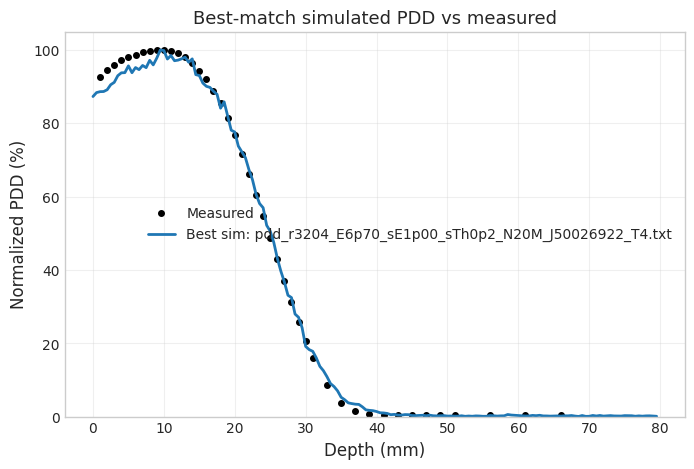

In [163]:
from pathlib import Path

# -------- matcher settings --------
pdd_search_glob = 'build/pdd*.txt'   # adjust path/pattern
candidate_limit = 200                # safety cap

# weights for combined score (lower is better)
w_curve_rmse = 1.0
w_curve_mae = 0.6
w_phys = 0.35

# optional fixed geometry conversion for all candidates
matcher_depth_bin_mm = pdd_depth_bin_mm
matcher_depth_offset_mm = pdd_depth_offset_mm
matcher_depth_scale = sim_depth_scale
matcher_depth_shift_mm = sim_depth_shift_mm
# -------------------------------


def metric_abs_diff(a, b):
    if np.isnan(a) or np.isnan(b):
        return np.nan
    return abs(float(a) - float(b))


def evaluate_pdd_candidate(pdd_path):
    sim_df = read_pdd_file(
        pdd_path,
        depth_bin_mm=matcher_depth_bin_mm,
        depth_offset_mm=matcher_depth_offset_mm,
    ).copy()

    # apply same optional correction used in main flow
    sim_df['depth_mm'] = sim_df['depth_mm'] * matcher_depth_scale + matcher_depth_shift_mm

    sim_norm_local, _ = normalize_to_dmax(sim_df['depth_mm'].values, sim_df['dose'].values)
    sim_on_meas_local = np.interp(meas_df['depth_mm'].values, sim_df['depth_mm'].values, sim_norm_local)

    comp_local = pd.DataFrame({
        'depth_mm': meas_df['depth_mm'].values,
        'measured_norm_pct': meas_norm,
        'sim_norm_pct_interp': sim_on_meas_local,
    })
    comp_local['delta_pctpts'] = comp_local['sim_norm_pct_interp'] - comp_local['measured_norm_pct']
    comp_local['abs_delta_pctpts'] = comp_local['delta_pctpts'].abs()

    # curve metrics
    rmse = float(np.sqrt(np.mean(comp_local['delta_pctpts']**2)))
    mae = float(comp_local['abs_delta_pctpts'].mean())
    maxabs = float(comp_local['abs_delta_pctpts'].max())

    # physics metrics
    sim_phys_local = pdd_metrics_full(sim_df['depth_mm'].values, sim_norm_local, use_robust_dmax=True)
    meas_phys_local = pdd_metrics_full(meas_df['depth_mm'].values, meas_norm, use_robust_dmax=False)

    phys_keys = ['dmax_mm', 'R90_mm', 'R80_mm', 'R50_mm', 'R20_mm', 'Rp_est_mm']
    phys_diffs = [metric_abs_diff(sim_phys_local[k], meas_phys_local[k]) for k in phys_keys]
    phys_mae = float(np.nanmean(phys_diffs))

    score = w_curve_rmse*rmse + w_curve_mae*mae + w_phys*phys_mae

    return {
        'file': str(pdd_path),
        'score': score,
        'RMSE_pctpts': rmse,
        'MAE_pctpts': mae,
        'MaxAbs_pctpts': maxabs,
        'Phys_MAE_mm': phys_mae,
        'dmax_abs_mm': metric_abs_diff(sim_phys_local['dmax_mm'], meas_phys_local['dmax_mm']),
        'R90_abs_mm': metric_abs_diff(sim_phys_local['R90_mm'], meas_phys_local['R90_mm']),
        'R80_abs_mm': metric_abs_diff(sim_phys_local['R80_mm'], meas_phys_local['R80_mm']),
        'R50_abs_mm': metric_abs_diff(sim_phys_local['R50_mm'], meas_phys_local['R50_mm']),
        'R20_abs_mm': metric_abs_diff(sim_phys_local['R20_mm'], meas_phys_local['R20_mm']),
        'Rp_abs_mm': metric_abs_diff(sim_phys_local['Rp_est_mm'], meas_phys_local['Rp_est_mm']),
    }


# run matcher
candidate_files = sorted(Path('.').glob(pdd_search_glob))[:candidate_limit]
if not candidate_files:
    raise FileNotFoundError(f'No files matched: {pdd_search_glob}')

rows = []
for fp in candidate_files:
    try:
        rows.append(evaluate_pdd_candidate(fp))
    except Exception as e:
        rows.append({'file': str(fp), 'score': np.inf, 'error': str(e)})

rank_df = pd.DataFrame(rows).sort_values('score', na_position='last').reset_index(drop=True)

print(f'Candidates evaluated: {len(candidate_files)}')
pd.set_option('display.max_colwidth', None)
display(rank_df.head(15))

# plot top match vs measured
best = rank_df.iloc[0]
if np.isfinite(best['score']):
    best_df = read_pdd_file(
        best['file'],
        depth_bin_mm=matcher_depth_bin_mm,
        depth_offset_mm=matcher_depth_offset_mm,
    ).copy()
    best_df['depth_mm'] = best_df['depth_mm'] * matcher_depth_scale + matcher_depth_shift_mm
    best_norm, _ = normalize_to_dmax(best_df['depth_mm'].values, best_df['dose'].values)

    plt.figure(figsize=(8,5))
    plt.plot(meas_df['depth_mm'], meas_norm, 'o', ms=4, label='Measured', color='black')
    plt.plot(best_df['depth_mm'], best_norm, '-', lw=2, label=f"Best sim: {Path(best['file']).name}")
    plt.xlabel('Depth (mm)')
    plt.ylabel('Normalized PDD (%)')
    plt.title('Best-match simulated PDD vs measured')
    plt.ylim(0, 105)
    plt.legend(frameon=False)
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('No valid candidate could be parsed. Check file format/settings.')

    



## 11) Best-match selector by mode-group (publication-grade)

This section adds **two dedicated blocks**:
1. Best simulated PDD that jointly fits **conv9 + flash9** for a selected applicator.
2. Best simulated PDD that fits **flash6alt** for a selected applicator.

Each block ranks candidate simulation files using both curve-fit and publication-style physics parameters, and outputs ranked tables + best-file parameter tables.

In [164]:
# Shared helper for grouped matching (conv9+flash9 and flash6alt)

def measured_for_mode(applicator_cm_sel, mode_sel):
    m = MEASURED_PDD[(applicator_cm_sel, mode_sel)]
    d = m['depth_mm'].astype(float)
    y = m['norm_pct'].astype(float)
    y_norm, _ = normalize_to_dmax(d, y)
    return d, y_norm


def score_sim_vs_measured(sim_depth, sim_norm, meas_depth, meas_norm, phys_weight=0.35):
    sim_on_meas = np.interp(meas_depth, sim_depth, sim_norm)
    delta = sim_on_meas - meas_norm
    abs_delta = np.abs(delta)

    rmse = float(np.sqrt(np.mean(delta**2)))
    mae = float(np.mean(abs_delta))
    maxabs = float(np.max(abs_delta))

    sim_phys = pdd_metrics_full(sim_depth, sim_norm, use_robust_dmax=True)
    meas_phys = pdd_metrics_full(meas_depth, meas_norm, use_robust_dmax=False)
    phys_keys = ['dmax_mm', 'R90_mm', 'R80_mm', 'R50_mm', 'R20_mm', 'Rp_est_mm']
    phys_mae = float(np.nanmean([abs(sim_phys[k]-meas_phys[k]) for k in phys_keys]))

    # publication-style combined score (lower is better)
    score = rmse + 0.6*mae + phys_weight*phys_mae
    return {
        'score': score,
        'RMSE_pctpts': rmse,
        'MAE_pctpts': mae,
        'MaxAbs_pctpts': maxabs,
        'Phys_MAE_mm': phys_mae,
        'sim_phys': sim_phys,
        'meas_phys': meas_phys,
    }


def load_sim_pdd_for_matching(path):
    df = read_pdd_file(path, depth_bin_mm=pdd_depth_bin_mm, depth_offset_mm=pdd_depth_offset_mm).copy()
    df['depth_mm'] = df['depth_mm'] * sim_depth_scale + sim_depth_shift_mm
    sim_norm_local, _ = normalize_to_dmax(df['depth_mm'].values, df['dose'].values)
    return df['depth_mm'].values, sim_norm_local



In [165]:
# -------- Block A: best single simulation fitting conv9 + flash9 together --------
match_applicator_cm = 10          # set 10, 5, or 2
joint_modes = ('conv9', 'flash9')
search_glob_joint = 'build/pdd*.txt'
max_candidates_joint = 300

candidate_files_joint = sorted(Path('.').glob(search_glob_joint))[:max_candidates_joint]
if not candidate_files_joint:
    raise FileNotFoundError(f'No files matched: {search_glob_joint}')

joint_rows = []
for fp in candidate_files_joint:
    try:
        sim_depth, sim_norm_local = load_sim_pdd_for_matching(fp)

        mode_scores = {}
        agg_score = 0.0
        agg_rmse = 0.0
        agg_mae = 0.0
        agg_phys = 0.0
        agg_maxabs = 0.0

        for md in joint_modes:
            meas_d, meas_n = measured_for_mode(match_applicator_cm, md)
            s = score_sim_vs_measured(sim_depth, sim_norm_local, meas_d, meas_n)
            mode_scores[md] = s
            agg_score += s['score']
            agg_rmse += s['RMSE_pctpts']
            agg_mae += s['MAE_pctpts']
            agg_phys += s['Phys_MAE_mm']
            agg_maxabs = max(agg_maxabs, s['MaxAbs_pctpts'])

        n = len(joint_modes)
        joint_rows.append({
            'file': str(fp),
            'score_joint': agg_score / n,
            'RMSE_avg': agg_rmse / n,
            'MAE_avg': agg_mae / n,
            'Phys_MAE_avg_mm': agg_phys / n,
            'MaxAbs_worst_pctpts': agg_maxabs,
            'conv9_RMSE': mode_scores['conv9']['RMSE_pctpts'],
            'flash9_RMSE': mode_scores['flash9']['RMSE_pctpts'],
            'conv9_R50': mode_scores['conv9']['sim_phys']['R50_mm'],
            'flash9_R50': mode_scores['flash9']['sim_phys']['R50_mm'],
        })
    except Exception as e:
        joint_rows.append({'file': str(fp), 'score_joint': np.inf, 'error': str(e)})

joint_rank_df = pd.DataFrame(joint_rows).sort_values('score_joint', na_position='last').reset_index(drop=True)
print(f'Joint-mode candidates evaluated: {len(candidate_files_joint)}')
display(joint_rank_df.head(15))

best_joint = joint_rank_df.iloc[0]
print('Best file for conv9+flash9 (joint):', best_joint['file'])

# publication-style parameter table for best joint file
sim_depth_b, sim_norm_b = load_sim_pdd_for_matching(best_joint['file'])
phys_rows = []
for md in joint_modes:
    meas_d, meas_n = measured_for_mode(match_applicator_cm, md)
    s = score_sim_vs_measured(sim_depth_b, sim_norm_b, meas_d, meas_n)
    row = {'mode': md, 'file': best_joint['file'],
           'RMSE_pctpts': s['RMSE_pctpts'], 'MAE_pctpts': s['MAE_pctpts'],
           'Phys_MAE_mm': s['Phys_MAE_mm']}
    for k in ['dmax_mm', 'R90_mm', 'R80_mm', 'R50_mm', 'R20_mm', 'Rp_est_mm']:
        row[f'sim_{k}'] = s['sim_phys'][k]
        row[f'meas_{k}'] = s['meas_phys'][k]
        row[f'delta_{k}'] = s['sim_phys'][k] - s['meas_phys'][k]
    phys_rows.append(row)

joint_best_table = pd.DataFrame(phys_rows)
print('Best-file publication parameter table (conv9 + flash9):')
display(joint_best_table.round(3))



Joint-mode candidates evaluated: 60


,file,score_joint,RMSE_avg,MAE_avg,Phys_MAE_avg_mm,MaxAbs_worst_pctpts,conv9_RMSE,flash9_RMSE,conv9_R50,flash9_R50
0,build/pdd_r1008_E9p70_sE1p30_sTh0p2_N20M_J50026587_T8.txt,3.875106,2.347701,1.962210,1.000226,5.045141,2.270926,2.424476,38.264778,38.264778
1,build/pdd_r1303_E9p700_sE1p28_sTh0p2_N30M_J50026608_T3.txt,4.101241,2.394882,2.056317,1.350196,5.480765,2.212460,2.577304,38.201446,38.201446
2,build/pdd_r1308_E9p690_sE1p26_sTh0p2_N30M_J50026615_T8.txt,4.267951,2.588938,2.094505,1.206599,6.867487,2.397066,2.780811,38.007206,38.007206
3,build/pdd_r508_E9p700_sE1p30_sTh0p2_N40M_J50026550_T2.txt,4.424667,2.618574,2.202516,1.384523,6.055654,2.469186,2.767962,38.047470,38.047470
4,build/pdd_r8010_E9p70_sE1p30_sTh0p2_N50M_J50026748_T1.txt,4.452360,2.616439,2.216012,1.446611,6.042674,2.447722,2.785156,38.063645,38.063645
5,build/pdd_r1316_E9p680_sE1p30_sTh0p2_N30M_J50026626_T16.txt,4.518876,2.742082,2.224902,1.262438,7.090136,2.624251,2.859913,37.979921,37.979921
6,build/pdd_r1301_E9p700_sE1p24_sTh0p2_N30M_J50026606_T1.txt,4.520082,2.650031,2.135032,1.682946,6.543099,2.498823,2.801240,38.025929,38.025929
7,build/pdd_r507_E9p700_sE1p30_sTh0p2_N30M_J50026548_T1.txt,4.535221,2.715097,2.182209,1.459427,8.058294,2.509535,2.920659,38.062481,38.062481
8,build/pdd_r805_E9p700_sE1p27_sTh0p2_N10M_J50026565_T5.txt,4.579368,2.753422,2.217251,1.415986,7.027813,2.682678,2.824166,37.490978,37.490978
9,build/pdd_r507_E9p700_sE1p30_sTh0p2_N20M_J50026540_T1.txt,4.594081,2.796584,2.236801,1.301189,8.505929,2.564895,3.028273,38.172737,38.172737


Best file for conv9+flash9 (joint): build/pdd_r1008_E9p70_sE1p30_sTh0p2_N20M_J50026587_T8.txt
Best-file publication parameter table (conv9 + flash9):


,mode,file,RMSE_pctpts,MAE_pctpts,Phys_MAE_mm,sim_dmax_mm,meas_dmax_mm,delta_dmax_mm,sim_R90_mm,meas_R90_mm,...,delta_R80_mm,sim_R50_mm,meas_R50_mm,delta_R50_mm,sim_R20_mm,meas_R20_mm,delta_R20_mm,sim_Rp_est_mm,meas_Rp_est_mm,delta_Rp_est_mm
0,conv9,build/pdd_r1008_E9p70_sE1p30_sTh0p2_N20M_J50026587_T8.txt,2.271,1.906,1.032,16.6,14.0,2.6,27.773,27.146,...,-0.13,38.265,39.292,-1.027,45.248,45.929,-0.681,42.591,43.721,-1.130
1,flash9,build/pdd_r1008_E9p70_sE1p30_sTh0p2_N20M_J50026587_T8.txt,2.424,2.019,0.968,16.6,14.0,2.6,27.773,28.097,...,-0.49,38.265,39.147,-0.883,45.248,45.790,-0.541,42.591,43.562,-0.971


In [166]:
# -------- Block B: best simulation fitting flash6alt --------
flash6_applicator_cm = 10         # set 10, 5, or 2
flash6_mode = 'flash6alt'
search_glob_flash6 = 'build/pdd*.txt'
max_candidates_flash6 = 300

candidate_files_f6 = sorted(Path('.').glob(search_glob_flash6))[:max_candidates_flash6]
if not candidate_files_f6:
    raise FileNotFoundError(f'No files matched: {search_glob_flash6}')

f6_rows = []
meas_d_f6, meas_n_f6 = measured_for_mode(flash6_applicator_cm, flash6_mode)

for fp in candidate_files_f6:
    try:
        sim_depth, sim_norm_local = load_sim_pdd_for_matching(fp)
        s = score_sim_vs_measured(sim_depth, sim_norm_local, meas_d_f6, meas_n_f6)
        f6_rows.append({
            'file': str(fp),
            'score_flash6': s['score'],
            'RMSE_pctpts': s['RMSE_pctpts'],
            'MAE_pctpts': s['MAE_pctpts'],
            'MaxAbs_pctpts': s['MaxAbs_pctpts'],
            'Phys_MAE_mm': s['Phys_MAE_mm'],
            'R50_sim_mm': s['sim_phys']['R50_mm'],
            'R50_meas_mm': s['meas_phys']['R50_mm'],
            'dmax_sim_mm': s['sim_phys']['dmax_mm'],
            'dmax_meas_mm': s['meas_phys']['dmax_mm'],
        })
    except Exception as e:
        f6_rows.append({'file': str(fp), 'score_flash6': np.inf, 'error': str(e)})

f6_rank_df = pd.DataFrame(f6_rows).sort_values('score_flash6', na_position='last').reset_index(drop=True)
print(f'flash6alt candidates evaluated: {len(candidate_files_f6)}')
display(f6_rank_df.head(15))

best_f6 = f6_rank_df.iloc[0]
print('Best file for flash6alt:', best_f6['file'])

sim_depth_f6b, sim_norm_f6b = load_sim_pdd_for_matching(best_f6['file'])
s_f6_best = score_sim_vs_measured(sim_depth_f6b, sim_norm_f6b, meas_d_f6, meas_n_f6)

f6_param_table = pd.DataFrame([{
    'mode': flash6_mode,
    'file': best_f6['file'],
    'RMSE_pctpts': s_f6_best['RMSE_pctpts'],
    'MAE_pctpts': s_f6_best['MAE_pctpts'],
    'Phys_MAE_mm': s_f6_best['Phys_MAE_mm'],
    **{f'sim_{k}': v for k, v in s_f6_best['sim_phys'].items()},
    **{f'meas_{k}': v for k, v in s_f6_best['meas_phys'].items()},
    **{f'delta_{k}': s_f6_best['sim_phys'][k] - s_f6_best['meas_phys'][k] for k in s_f6_best['sim_phys'].keys()},
}])

print('Best-file publication parameter table (flash6alt):')
display(f6_param_table.round(3))



flash6alt candidates evaluated: 60


,file,score_flash6,RMSE_pctpts,MAE_pctpts,MaxAbs_pctpts,Phys_MAE_mm,R50_sim_mm,R50_meas_mm,dmax_sim_mm,dmax_meas_mm
0,build/pdd_r3204_E6p70_sE1p00_sTh0p2_N20M_J50026922_T4.txt,2.943734,1.953125,1.434694,5.375771,0.370837,25.093576,24.789127,9.750000,9.0
1,build/pdd_r3203_E6p70_sE0p90_sTh0p2_N20M_J50026919_T3.txt,3.464055,2.252362,1.615612,5.718557,0.692358,24.939108,24.789127,11.700000,9.0
2,build/pdd_r3009_E6p80_sE0p80_sTh0p2_N20M_J50026863_T9.txt,4.552671,2.952650,2.182176,6.614747,0.830615,25.186347,24.789127,10.250000,9.0
3,build/pdd_r3206_E6p80_sE0p80_sTh0p2_N20M_J50026926_T6.txt,4.552671,2.952650,2.182176,6.614747,0.830615,25.186347,24.789127,10.250000,9.0
4,build/pdd_r3202_E6p70_sE0p80_sTh0p2_N20M_J50026915_T2.txt,4.670534,2.999945,2.192678,6.486381,1.014235,24.568913,24.789127,11.750000,9.0
5,build/pdd_r3008_E6p70_sE0p80_sTh0p2_N20M_J50026859_T8.txt,4.670534,2.999945,2.192678,6.486381,1.014235,24.568913,24.789127,11.750000,9.0
6,build/pdd_r3205_E6p80_sE0p70_sTh0p2_N20M_J50026924_T5.txt,4.969061,3.184894,2.349611,7.175823,1.069714,25.083535,24.789127,11.625000,9.0
7,build/pdd_r3201_E6p70_sE0p70_sTh0p2_N20M_J50026914_T1.txt,5.062409,3.222562,2.435944,6.870315,1.080801,24.559705,24.789127,12.500000,9.0
8,build/pdd_r3010_E6p90_sE0p80_sTh0p2_N20M_J50026864_T10.txt,5.264434,3.411861,2.596699,7.566853,0.841580,25.456594,24.789127,9.375000,9.0
9,build/pdd_r3007_E6p60_sE0p80_sTh0p2_N20M_J50026854_T7.txt,6.146570,3.947278,3.056338,8.460350,1.044254,23.711358,24.789127,10.500000,9.0


Best file for flash6alt: build/pdd_r3204_E6p70_sE1p00_sTh0p2_N20M_J50026922_T4.txt
Best-file publication parameter table (flash6alt):


,mode,file,RMSE_pctpts,MAE_pctpts,Phys_MAE_mm,sim_dmax_mm,sim_R90_mm,sim_R80_mm,sim_R50_mm,sim_R20_mm,...,meas_R80_mm,meas_R50_mm,meas_R20_mm,meas_Rp_est_mm,delta_dmax_mm,delta_R90_mm,delta_R80_mm,delta_R50_mm,delta_R20_mm,delta_Rp_est_mm
0,flash6alt,build/pdd_r3204_E6p70_sE1p00_sTh0p2_N20M_J50026922_T4.txt,1.953,1.435,0.371,9.75,16.122,19.254,25.094,29.914,...,19.314,24.789,30.161,27.768,0.75,-0.53,-0.059,0.304,-0.247,0.335


## 12) Comprehensive publication comparison (PDD + profiles)

This section provides the requested workflow in **three blocks**:
1. **PDD block**: pointwise % difference, RMSE/MAE, beam metrics (`dmax`, `R90`, `R80`, `R50`, `R30`, `R20`, `Rp`), gamma analysis, and max discrepancy within `R30`.
2. **Profile-depth blocks**: evaluate profiles at **dmax**, **middepth**, and **R50** with overlay + pointwise % diff + gamma + max discrepancy inside field.
3. **Fit summary block**: pass/fail readability table for both PDD and profile comparisons.

In [167]:
# ===== Block 1: PDD comprehensive comparison =====
# Select dataset to compare
compare_applicator_cm = 10
compare_mode = 'flash9'   # 'flash9', 'conv9', 'flash6alt'

compare_pdd_file = pdd_file  # reuse from user controls or set another file

# Section 5 Block 1 controls for simulation PDD treatment
# Positive shift moves simulation deeper; negative shift makes it shallower.
sim_compare_depth_shift_mm = 0.0

# dmax method options for SIMULATION only: 'argmax' (normal single-bin) or 'plateau' (robust plateau midpoint)
sim_compare_dmax_method = 'plateau'
sim_compare_dmax_frac = 0.99

# gamma criteria for PDD visualization panel
pdd_gamma_dose_crit = 2.0
pdd_gamma_dta_mm = 2.0

# acceptance criteria (edit for your study)
pdd_rmse_tol = 3.0
pdd_mae_tol = 2.5
pdd_gamma_passrate_tol = 90.0
pdd_r30_maxdisc_tol = 3.0  # pct-points


def pdd_metrics_extended(depth_mm, pdd_norm, dmax_method='argmax', dmax_frac=0.99):
    r90 = float(find_depth_at_percent(depth_mm, pdd_norm, 90))
    r80 = float(find_depth_at_percent(depth_mm, pdd_norm, 80))
    r50 = float(find_depth_at_percent(depth_mm, pdd_norm, 50))
    r30 = float(find_depth_at_percent(depth_mm, pdd_norm, 30))
    r20 = float(find_depth_at_percent(depth_mm, pdd_norm, 20))
    dmax = pick_dmax(depth_mm, pdd_norm, dmax_method=dmax_method, frac=dmax_frac)
    rp = 1.10*r50 + 0.5 if np.isfinite(r50) else np.nan
    return {'dmax_mm': dmax, 'R90_mm': r90, 'R80_mm': r80, 'R50_mm': r50, 'R30_mm': r30, 'R20_mm': r20, 'Rp_est_mm': float(rp)}


def gamma_1d(ref_x, ref_y, eval_x, eval_y, dose_crit=3.0, dta_crit_mm=2.0):
    # simple global 1D gamma (reference = measured)
    g = np.full_like(ref_y, np.nan, dtype=float)
    for i, (x0, y0) in enumerate(zip(ref_x, ref_y)):
        dist = np.abs(eval_x - x0)
        dd = np.abs(eval_y - y0)
        gam = np.sqrt((dist / dta_crit_mm)**2 + (dd / dose_crit)**2)
        g[i] = np.nanmin(gam)
    return g


meas_sel = MEASURED_PDD[(compare_applicator_cm, compare_mode)]
meas_depth = meas_sel['depth_mm'].astype(float)
meas_norm_raw = meas_sel['norm_pct'].astype(float)
meas_norm, _ = normalize_to_dmax(meas_depth, meas_norm_raw)

sim_df_cmp = read_pdd_file(compare_pdd_file, depth_bin_mm=pdd_depth_bin_mm, depth_offset_mm=pdd_depth_offset_mm).copy()
sim_df_cmp['depth_mm'] = sim_df_cmp['depth_mm'] * sim_depth_scale + sim_depth_shift_mm + sim_compare_depth_shift_mm

# This shifted depth axis is treated as the active/new simulation PDD for this block.
sim_norm_cmp, sim_dmax_cmp = normalize_to_dmax(
    sim_df_cmp['depth_mm'].values,
    sim_df_cmp['dose'].values,
    dmax_method=sim_compare_dmax_method,
    frac=sim_compare_dmax_frac,
)
sim_interp = np.interp(meas_depth, sim_df_cmp['depth_mm'].values, sim_norm_cmp)

pdd_comp = pd.DataFrame({'depth_mm': meas_depth, 'measured_pct': meas_norm, 'sim_pct': sim_interp})
pdd_comp['delta_pctpts'] = pdd_comp['sim_pct'] - pdd_comp['measured_pct']
pdd_comp['abs_delta_pctpts'] = np.abs(pdd_comp['delta_pctpts'])
pdd_comp['pointwise_pct_diff'] = np.where(np.abs(pdd_comp['measured_pct']) > 1e-9,
                                           100.0 * pdd_comp['delta_pctpts'] / pdd_comp['measured_pct'], np.nan)

# gamma + R30 discrepancy
gamma_vals = gamma_1d(
    meas_depth, meas_norm,
    sim_df_cmp['depth_mm'].values, sim_norm_cmp,
    dose_crit=pdd_gamma_dose_crit, dta_crit_mm=pdd_gamma_dta_mm,
)
pdd_gamma_pass = float(100.0 * np.mean(gamma_vals <= 1.0))

meas_phys = pdd_metrics_extended(meas_depth, meas_norm, dmax_method='argmax', dmax_frac=sim_compare_dmax_frac)
sim_phys = pdd_metrics_extended(
    sim_df_cmp['depth_mm'].values,
    sim_norm_cmp,
    dmax_method=sim_compare_dmax_method,
    dmax_frac=sim_compare_dmax_frac,
)
r30 = meas_phys['R30_mm']
r30_region = pdd_comp[pdd_comp['depth_mm'] <= r30] if np.isfinite(r30) else pdd_comp
max_disc_r30 = float(r30_region['abs_delta_pctpts'].max()) if len(r30_region) else np.nan

pdd_summary = {
    'RMSE_pctpts': float(np.sqrt(np.mean(pdd_comp['delta_pctpts']**2))),
    'MAE_pctpts': float(pdd_comp['abs_delta_pctpts'].mean()),
    'MaxAbs_pctpts': float(pdd_comp['abs_delta_pctpts'].max()),
    f'Gamma_pass_%_{pdd_gamma_dose_crit:.0f}pct_{pdd_gamma_dta_mm:.0f}mm': pdd_gamma_pass,
    'MaxDiscrepancy_within_R30_pctpts': max_disc_r30,
}

phys_table = pd.DataFrame({'Measured': meas_phys, 'Simulation': sim_phys})
phys_table['Sim-Meas'] = phys_table['Simulation'] - phys_table['Measured']

# visuals
fig, ax = plt.subplots(3,1, figsize=(8,9), sharex=True, gridspec_kw={'height_ratios':[3,1.3,1.3], 'hspace':0.08})
ax[0].plot(meas_depth, meas_norm, 'o', ms=4, color='black', label='Measured')
ax[0].plot(sim_df_cmp['depth_mm'], sim_norm_cmp, '-', lw=2, color='tab:blue', label='Simulation')
ax[0].set_ylabel('PDD (%)')
ax[0].set_title(f'PDD comprehensive compare | {compare_applicator_cm} cm | {compare_mode}')
ax[0].set_ylim(0,105)
ax[0].legend(frameon=False)
ax[0].grid(True, alpha=0.3)

ax[1].axhline(0,color='k',lw=1)
ax[1].plot(pdd_comp['depth_mm'], pdd_comp['pointwise_pct_diff'], 'o-', ms=3.2, lw=1.2, color='tab:orange')
ax[1].set_ylabel('Pct diff
((S-M)/M %)')
ax[1].grid(True, alpha=0.3)

ax[2].axhline(1.0, color='k', lw=1, ls='--')
ax[2].plot(meas_depth, gamma_vals, 'o-', ms=3.2, lw=1.2, color='tab:green')
ax[2].set_ylabel(f'Gamma
({pdd_gamma_dose_crit:.0f}%/{pdd_gamma_dta_mm:.0f}mm)')
ax[2].set_xlabel('Depth (mm)')
ax[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Simulation depth shift applied in this block: {sim_compare_depth_shift_mm:+.3f} mm")
print(f"Simulation dmax method: {sim_compare_dmax_method} (frac={sim_compare_dmax_frac})")
print(f"Simulation dmax used in this block: {sim_dmax_cmp:.3f} mm")
print('PDD summary metrics:')
display(pd.DataFrame([pdd_summary]).round(3))
print('PDD physics parameter table:')
display(phys_table.round(3))



SyntaxError: unterminated string literal (detected at line 114) (1415323976.py, line 114)

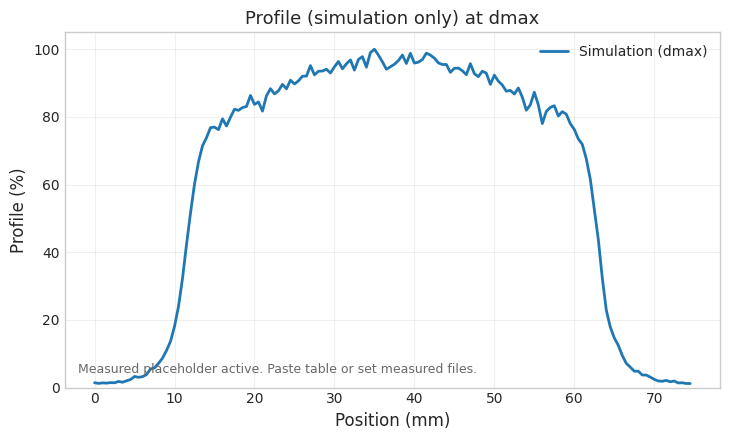

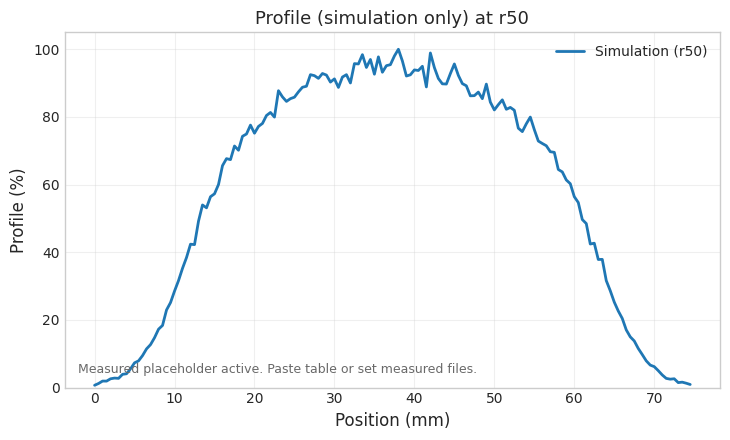

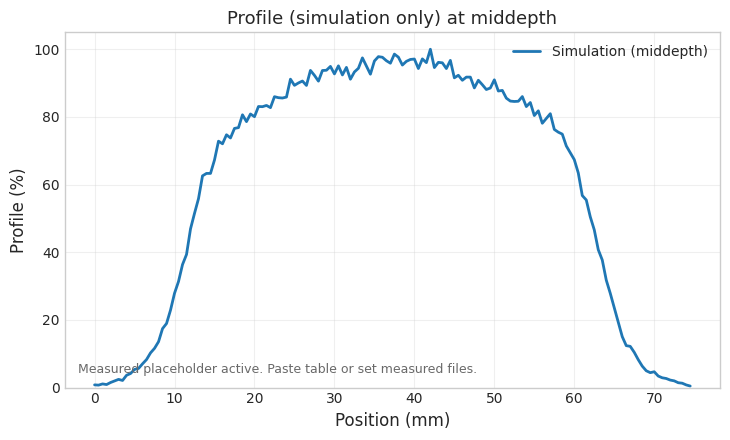

Profile comparison summary:


,depth_key,status,RMSE_pctpts,MAE_pctpts,MaxAbs_pctpts,Gamma_pass_%_2pct_2mm,MaxDisc_inField_pctpts
0,dmax,sim_only,NaN,NaN,NaN,NaN,NaN
1,r50,sim_only,NaN,NaN,NaN,NaN,NaN
2,middepth,sim_only,NaN,NaN,NaN,NaN,NaN


In [168]:
# ===== Block 2: Profile comparison at dmax/rmax, middepth, R50 =====
profile_depth_keys = lateral_profile_depth_keys
measured_profile_files = measured_lateral_files
sim_profile_files = sim_lateral_files

profile_position_axis = profile_axis
profile_bin_mm = profile_position_bin_mm
profile_offset_mm = profile_position_offset_mm

profile_gamma_dose_crit = 2.0
profile_gamma_dta_mm = 2.0
field_cut_percent = 50.0

profile_rows = []

for key in profile_depth_keys:
    mfile = measured_profile_files.get(key)
    sfile = sim_profile_files.get(key)

    if not sfile:
        profile_rows.append({'depth_key': key, 'status': 'missing_sim_file'})
        continue

    sdf = read_profile_file(sfile, y_name='sim', position_axis=profile_position_axis,
                            position_bin_mm=profile_bin_mm, position_offset_mm=profile_offset_mm)
    sdf['position_mm'] = sdf['position_mm'] * sim_position_scale + sim_position_shift_mm
    sim_prof = normalize_profile(sdf['sim'].values)

    if mfile:
        mdf = read_profile_file(mfile, y_name='meas', position_axis=profile_position_axis,
                                position_bin_mm=profile_bin_mm, position_offset_mm=profile_offset_mm)
    elif 'measured_lateral_profiles_data' in globals() and key in measured_lateral_profiles_data:
        mdf = measured_lateral_profiles_data[key].copy()
    else:
        mdf = None

    if mdf is None:
        profile_rows.append({'depth_key': key, 'status': 'sim_only', 'RMSE_pctpts': np.nan, 'MAE_pctpts': np.nan,
                             'MaxAbs_pctpts': np.nan, f'Gamma_pass_%_{profile_gamma_dose_crit:.0f}pct_{profile_gamma_dta_mm:.0f}mm': np.nan,
                             'MaxDisc_inField_pctpts': np.nan})
        plt.figure(figsize=(7.4,4.5))
        plt.plot(sdf['position_mm'], sim_prof, '-', lw=2, color='tab:blue', label=f'Simulation ({key})')
        plt.title(f'Profile (simulation only) at {key}')
        plt.ylabel('Profile (%)'); plt.xlabel('Position (mm)'); plt.ylim(0,105)
        plt.grid(True, alpha=0.3); plt.legend(frameon=False)
        plt.text(0.02, 0.04, 'Measured placeholder active. Paste table or set measured files.', transform=plt.gca().transAxes, fontsize=9, color='dimgray')
        plt.tight_layout(); plt.show()
        continue

    mdf['position_mm'] = mdf['position_mm'] * sim_position_scale + sim_position_shift_mm
    meas_prof = normalize_profile(mdf['meas'].values)
    sim_interp = np.interp(mdf['position_mm'].values, sdf['position_mm'].values, sim_prof)

    comp = pd.DataFrame({'x_mm': mdf['position_mm'].values, 'measured_pct': meas_prof, 'sim_pct': sim_interp})
    comp['delta_pctpts'] = comp['sim_pct'] - comp['measured_pct']
    comp['abs_delta_pctpts'] = np.abs(comp['delta_pctpts'])
    comp['pointwise_pct_diff'] = np.where(np.abs(comp['measured_pct']) > 1e-9,
                                          100.0*comp['delta_pctpts']/comp['measured_pct'], np.nan)

    g = gamma_1d(comp['x_mm'].values, comp['measured_pct'].values,
                 sdf['position_mm'].values, sim_prof,
                 dose_crit=profile_gamma_dose_crit, dta_crit_mm=profile_gamma_dta_mm)
    gpass = float(100.0*np.mean(g <= 1.0))

    in_field = comp['measured_pct'] >= field_cut_percent
    max_disc_field = float(comp.loc[in_field, 'abs_delta_pctpts'].max()) if np.any(in_field) else np.nan

    profile_rows.append({'depth_key': key, 'status': 'ok',
                         'RMSE_pctpts': float(np.sqrt(np.mean(comp['delta_pctpts']**2))),
                         'MAE_pctpts': float(np.mean(comp['abs_delta_pctpts'])),
                         'MaxAbs_pctpts': float(np.max(comp['abs_delta_pctpts'])),
                         f'Gamma_pass_%_{profile_gamma_dose_crit:.0f}pct_{profile_gamma_dta_mm:.0f}mm': gpass,
                         'MaxDisc_inField_pctpts': max_disc_field})

    fig, ax = plt.subplots(3,1, figsize=(7.6,8.2), sharex=True, gridspec_kw={'height_ratios':[3,1.2,1.2], 'hspace':0.08})
    ax[0].plot(comp['x_mm'], comp['measured_pct'], 'o', ms=4, color='black', label=f'Measured ({key})')
    ax[0].plot(comp['x_mm'], comp['sim_pct'], '-', lw=2, color='tab:blue', label=f'Simulation ({key})')
    ax[0].set_ylabel('Profile (%)')
    ax[0].set_title(f'Profile comparison at {key} | {lateral_mode_select} {lateral_applicator_select_cm} cm')
    ax[0].set_ylim(0,105); ax[0].legend(frameon=False); ax[0].grid(True, alpha=0.3)

    ax[1].axhline(0,color='k',lw=1)
    ax[1].plot(comp['x_mm'], comp['pointwise_pct_diff'], 'o-', ms=3.0, lw=1.2, color='tab:orange')
    ax[1].set_ylabel('Pct diff\n((S-M)/M %)'); ax[1].grid(True, alpha=0.3)

    ax[2].axhline(1.0, color='k', lw=1, ls='--')
    ax[2].plot(comp['x_mm'], g, 'o-', ms=3.0, lw=1.2, color='tab:green')
    ax[2].set_ylabel(f'Gamma\n({profile_gamma_dose_crit:.0f}%/{profile_gamma_dta_mm:.0f}mm)')
    ax[2].set_xlabel('Position (mm)'); ax[2].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

profile_summary_df = pd.DataFrame(profile_rows)
print('Profile comparison summary:')
display(profile_summary_df.round(3))



In [169]:
# ===== Block 3: Easy-to-read fit decision table (PDD + profile) =====
# thresholds (edit as needed for manuscript criteria)
profile_rmse_tol = 3.0
profile_mae_tol = 2.5
profile_gamma_passrate_tol = 90.0
profile_field_maxdisc_tol = 3.0

pdd_gamma_key = f"Gamma_pass_%_{pdd_gamma_dose_crit:.0f}pct_{pdd_gamma_dta_mm:.0f}mm"
profile_gamma_key = f"Gamma_pass_%_{profile_gamma_dose_crit:.0f}pct_{profile_gamma_dta_mm:.0f}mm"

pdd_fit_ok = (
    (pdd_summary['RMSE_pctpts'] <= pdd_rmse_tol) and
    (pdd_summary['MAE_pctpts'] <= pdd_mae_tol) and
    (pdd_summary[pdd_gamma_key] >= pdd_gamma_passrate_tol) and
    (pdd_summary['MaxDiscrepancy_within_R30_pctpts'] <= pdd_r30_maxdisc_tol)
)

profile_ok_flags = []
if 'profile_summary_df' in globals() and len(profile_summary_df):
    for _, r in profile_summary_df.iterrows():
        if r.get('status') != 'ok':
            profile_ok_flags.append(False)
            continue
        ok = (
            r['RMSE_pctpts'] <= profile_rmse_tol and
            r['MAE_pctpts'] <= profile_mae_tol and
            r[profile_gamma_key] >= profile_gamma_passrate_tol and
            r['MaxDisc_inField_pctpts'] <= profile_field_maxdisc_tol
        )
        profile_ok_flags.append(ok)

profile_fit_ok = bool(np.all(profile_ok_flags)) if profile_ok_flags else False

decision_table = pd.DataFrame([
    {
        'Comparison': 'PDD',
        'Fit_within_criteria': pdd_fit_ok,
        'RMSE': pdd_summary['RMSE_pctpts'],
        'MAE': pdd_summary['MAE_pctpts'],
        'Gamma_pass_%': pdd_summary[pdd_gamma_key],
        'MaxDiscrepancy_focus': pdd_summary['MaxDiscrepancy_within_R30_pctpts'],
    },
    {
        'Comparison': 'Profiles (dmax/middepth/R50)',
        'Fit_within_criteria': profile_fit_ok,
        'RMSE': float(np.nanmean(profile_summary_df.loc[profile_summary_df['status']=='ok', 'RMSE_pctpts'])) if 'profile_summary_df' in globals() and np.any(profile_summary_df['status']=='ok') else np.nan,
        'MAE': float(np.nanmean(profile_summary_df.loc[profile_summary_df['status']=='ok', 'MAE_pctpts'])) if 'profile_summary_df' in globals() and np.any(profile_summary_df['status']=='ok') else np.nan,
        'Gamma_pass_%': float(np.nanmean(profile_summary_df.loc[profile_summary_df['status']=='ok', profile_gamma_key])) if 'profile_summary_df' in globals() and np.any(profile_summary_df['status']=='ok') else np.nan,
        'MaxDiscrepancy_focus': float(np.nanmax(profile_summary_df.loc[profile_summary_df['status']=='ok', 'MaxDisc_inField_pctpts'])) if 'profile_summary_df' in globals() and np.any(profile_summary_df['status']=='ok') else np.nan,
    }
])

print('Fit decision table:')
display(decision_table.round(3))

if pdd_fit_ok and profile_fit_ok:
    print('✅ Overall: simulation and measurement fit within criteria for both PDD and profiles.')
else:
    print('⚠️ Overall: at least one comparison block is outside criteria; inspect summary tables above.')



NameError: name 'pdd_gamma_dose_crit' is not defined